# 1. Titulo y objetivo

# 3_modeling_experiments_cards

Este notebook implementa la fase de experimentacion para deteccion de fraude a nivel transaccional.

Objetivos operativos:
- cargar y validar `data/processed/transactions_modeling.parquet`
- construir el split temporal `train/validation/test`
- crear un ranking de variables usando solo `train` y `validation` cuando aplique
- entrenar modelos tradicionales y estrategias de balanceo sin tocar `test`
- guardar metricas, tablas, figuras y modelos candidatos para la seleccion final en el notebook 4

Restricciones metodologicas aplicadas en este notebook:
- no se usa `test` para ranking, subset selection, hiperparametros ni threshold
- no se usa SMOTE antes del split temporal
- no se usan variables con nombre sospechoso de derivar del target (`fraud`, `target`, `label`) como predictores
- se excluyen tambien features globales o de agregacion total potencialmente no causales (`global`, `overall`, `all_time`)
- si un modelo es demasiado costoso, se usa una muestra documentada de `train` o `validation`
- si una libreria no esta instalada o el costo es excesivo, el modelo se omite y se documenta la razon


# 2. Imports


In [21]:
from __future__ import annotations

import importlib.util
import json
import sys
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    IsolationForest,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import classification_report
from sklearn.naive_bayes import BernoulliNB, ComplementNB, GaussianNB
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, OneClassSVM, SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

RANDOM_STATE = 42


# 3. Conexion con `src`


In [22]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "src").exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.evaluate_models import (
    build_metrics_frame,
    evaluate_classifier,
    evaluate_validation_thresholds,
    get_positive_class_scores,
    save_metrics_table,
    save_threshold_table,
)
from src.models.feature_selection import (
    build_feature_ranking_table,
    create_feature_subsets,
    filter_constant_features,
    filter_correlated_features,
    rank_features_logistic_coefficients,
    rank_features_mutual_information,
    rank_features_permutation_importance,
    rank_features_tree_importance,
    save_feature_ranking,
)
from src.models.train_baseline import (
    build_decision_tree_baseline,
    build_dummy_baseline,
    build_logistic_baseline,
)
from src.models.train_models import (
    TemporalSplitConfig,
    build_candidate_feature_columns,
    build_hist_gradient_boosting_pipeline,
    build_preprocessor,
    build_random_forest_pipeline,
    build_random_undersample_logistic_pipeline,
    build_smote_logistic_pipeline,
    detect_identifier_columns,
    detect_target_column,
    get_modeling_dataset_columns,
    load_modeling_dataset_preview,
    load_temporal_split_dataset,
    make_estimator_pipeline,
    split_features_target,
    summarize_temporal_split_from_parquet,
    summarize_temporal_split_monthly_from_parquet,
    validate_modeling_dataset,
)
from src.utils.metrics import (
    build_threshold_table,
    compute_classification_metrics,
    get_predicted_labels,
    select_threshold,
)
from src.utils.plotting import (
    plot_confusion_matrix,
    plot_feature_importance,
    plot_precision_recall_curve,
    plot_roc_curve,
)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")

PROJECT_ROOT: c:\Users\cecor\OneDrive - Universidad Nacional de Colombia\GitHub\MSc-Thesis-Financial-Fraud-Detection-Models


# 4. Definicion de rutas


In [23]:
DATASET_PATH = PROJECT_ROOT / "data" / "processed" / "transactions_modeling.parquet"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
TABLES_DIR = OUTPUTS_DIR / "tables"
FIGURES_DIR = OUTPUTS_DIR / "figures"
MODELS_DIR = OUTPUTS_DIR / "models"
METRICS_DIR = OUTPUTS_DIR / "metrics"

for path in (OUTPUTS_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR, METRICS_DIR):
    path.mkdir(parents=True, exist_ok=True)

TEMPORAL_SPLIT = TemporalSplitConfig(
    train_start="1991-01",
    train_end="2017-12",
    validation_start="2018-01",
    validation_end="2018-12",
    test_start="2019-01",
    test_end="2019-10",
    excluded_periods=("2019-11", "2019-12", "2020-01", "2020-02"),
)

THRESHOLD_CRITERION = "f1"
RANKING_SUBSET_SIZES = (25, 50, 75, 100)

DATASET_PREVIEW_ROWS = 5
IN_MEMORY_TRAIN_ROWS = 500_000
IN_MEMORY_VALIDATION_ROWS = 200_000
RANKING_MAX_TRAIN_ROWS = 300_000
RANKING_MAX_VALIDATION_ROWS = 150_000
FEATURE_METADATA_MAX_ROWS = 250_000
CORRELATION_SAMPLE_SIZE = 200_000
MI_SAMPLE_SIZE = 200_000
LOGISTIC_RANKING_SAMPLE_SIZE = 150_000
TREE_RANKING_SAMPLE_SIZE = 150_000
PERMUTATION_MAX_TRAIN_ROWS = 200_000
PERMUTATION_MAX_VALIDATION_ROWS = 120_000

RUN_OPTIONAL_HEAVY_MODELS = True
RUN_ANOMALY_MODELS = True
RUN_GAN_EXPERIMENT = True
RUN_DEEP_LEARNING_EXPERIMENTS = True

MODEL_SAMPLE_LIMITS = {
    "dummy_classifier": {"max_train_rows": None, "max_validation_rows": None},
    "logistic_regression": {"max_train_rows": None, "max_validation_rows": None},
    "logistic_regression_undersample": {"max_train_rows": 500_000, "max_validation_rows": None},
    "logistic_regression_smote": {"max_train_rows": 300_000, "max_validation_rows": 200_000},
    "decision_tree": {"max_train_rows": None, "max_validation_rows": None},
    "random_forest": {"max_train_rows": None, "max_validation_rows": None},
    "extra_trees": {"max_train_rows": None, "max_validation_rows": None},
    "hist_gradient_boosting": {"max_train_rows": None, "max_validation_rows": None},
    "gradient_boosting": {"max_train_rows": 250_000, "max_validation_rows": 150_000},
    "adaboost": {"max_train_rows": 250_000, "max_validation_rows": 150_000},
    "bagging_tree": {"max_train_rows": 250_000, "max_validation_rows": 150_000},
    "xgboost": {"max_train_rows": 500_000, "max_validation_rows": 200_000},
    "sgd_classifier": {"max_train_rows": None, "max_validation_rows": None},
    "linear_svc": {"max_train_rows": None, "max_validation_rows": None},
    "svc_rbf": {"max_train_rows": 60_000, "max_validation_rows": 40_000},
    "knn": {"max_train_rows": 120_000, "max_validation_rows": 60_000},
    "gaussian_nb": {"max_train_rows": None, "max_validation_rows": None},
    "bernoulli_nb": {"max_train_rows": None, "max_validation_rows": None},
    "complement_nb": {"max_train_rows": None, "max_validation_rows": None},
    "mlp_classifier": {"max_train_rows": 350_000, "max_validation_rows": 200_000},
    "isolation_forest": {"max_train_rows": 250_000, "max_validation_rows": 150_000},
    "local_outlier_factor": {"max_train_rows": 60_000, "max_validation_rows": 40_000},
    "one_class_svm": {"max_train_rows": 50_000, "max_validation_rows": 30_000},
}

AVAILABLE_LIBRARIES = {
    "xgboost": importlib.util.find_spec("xgboost") is not None,
    "ctgan": importlib.util.find_spec("ctgan") is not None,
    "torch": importlib.util.find_spec("torch") is not None,
    "tensorflow": importlib.util.find_spec("tensorflow") is not None,
    "openpyxl": importlib.util.find_spec("openpyxl") is not None,
}

if AVAILABLE_LIBRARIES["xgboost"]:
    from xgboost import XGBClassifier

display(pd.Series(AVAILABLE_LIBRARIES, name="available"))

CTGAN_MAX_TRAIN_ROWS = 180_000
CTGAN_MAX_VALIDATION_ROWS = 120_000
CTGAN_POSITIVE_TRAIN_CAP = 25_000
CTGAN_SYNTHETIC_MULTIPLIER = 3
CTGAN_MAX_SYNTHETIC_ROWS = 60_000

XGB_CALIBRATED_MAX_TRAIN_ROWS = 180_000
XGB_CALIBRATED_MAX_VALIDATION_ROWS = 120_000
XGB_CALIBRATED_CV = 3

LIGHT_MLP_MAX_TRAIN_ROWS = 220_000
LIGHT_MLP_MAX_VALIDATION_ROWS = 120_000
LIGHT_MLP_MAX_ITER = 40
LIGHT_MLP_HIDDEN_LAYERS = (32, 16)

TORCH_MLP_MAX_TRAIN_ROWS = 250_000
TORCH_MLP_MAX_VALIDATION_ROWS = 120_000
TORCH_MLP_EPOCHS = 12
TORCH_MLP_BATCH_SIZE = 2048
TORCH_MLP_LR = 1e-3
TORCH_MLP_PATIENCE = 3

AUTOENCODER_MAX_NEGATIVE_TRAIN_ROWS = 200_000
AUTOENCODER_MAX_VALIDATION_ROWS = 120_000
AUTOENCODER_EPOCHS = 12
AUTOENCODER_BATCH_SIZE = 2048
AUTOENCODER_LR = 1e-3
AUTOENCODER_PATIENCE = 3


xgboost        True
ctgan          True
torch          True
tensorflow    False
openpyxl       True
Name: available, dtype: bool

# 5. Carga de `data/processed/transactions_modeling.parquet`


In [24]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"No se encontro el dataset de modelado: {DATASET_PATH}. "
        "Falta primero el notebook 2 para generar transactions_modeling.parquet."
    )

dataset_columns = get_modeling_dataset_columns(DATASET_PATH)
dataset_preview = load_modeling_dataset_preview(DATASET_PATH, n_rows=DATASET_PREVIEW_ROWS)
print(f"Preview shape: {dataset_preview.shape}")
dataset_preview.head(3)

Preview shape: (5, 217)


,user,card,user_card_id,datetime,year_month,merchant_name,merchant_city,merchant_state,zip,mcc,use_chip,is_fraud,amount_abs,amount_log,amount_is_negative,merchant_state_was_missing,zip_was_missing,hour,day_of_week,is_weekend,quarter,day_of_month,n_cards_user,is_online_transaction,is_chip_transaction,is_swipe_transaction,is_night,is_morning,is_afternoon,is_evening,is_business_hours,is_late_night,amount_above_global_p90_flag,amount_above_global_p95_flag,amount_above_global_p99_flag,amount_is_zero_flag,amount_below_1_flag,amount_below_5_flag,amount_is_round_10_flag,amount_is_round_100_flag,uc_tx_count_hist,uc_amount_sum_hist,uc_amount_mean_hist,uc_amount_max_hist,uc_days_since_prev_tx,uc_no_history_flag,first_transaction_flag,long_inactivity_30d_flag,long_inactivity_90d_flag,amount_to_hist_mean_ratio,amount_above_hist_max_flag,amount_gt_3x_hist_mean_flag,amount_gt_3x_12m_mean_flag,uc_tx_count_3m,uc_amount_sum_3m,uc_amount_mean_3m,uc_amount_min_3m,uc_amount_max_3m,uc_amount_std_3m,uc_avg_ticket_3m,uc_amount_cv_3m,uc_amount_max_mean_ratio_3m,uc_amount_min_mean_ratio_3m,uc_online_tx_count_3m,uc_online_tx_rate_3m,uc_negative_tx_count_3m,uc_negative_tx_rate_3m,uc_unique_merchants_3m,uc_unique_mcc_3m,uc_tx_count_6m,uc_amount_sum_6m,uc_amount_mean_6m,uc_amount_min_6m,uc_amount_max_6m,uc_amount_std_6m,uc_avg_ticket_6m,uc_amount_cv_6m,uc_amount_max_mean_ratio_6m,uc_amount_min_mean_ratio_6m,uc_online_tx_count_6m,uc_online_tx_rate_6m,uc_negative_tx_count_6m,uc_negative_tx_rate_6m,uc_unique_merchants_6m,uc_unique_mcc_6m,uc_tx_count_9m,uc_amount_sum_9m,uc_amount_mean_9m,uc_amount_min_9m,uc_amount_max_9m,uc_amount_std_9m,uc_avg_ticket_9m,uc_amount_cv_9m,uc_amount_max_mean_ratio_9m,uc_amount_min_mean_ratio_9m,uc_online_tx_count_9m,uc_online_tx_rate_9m,uc_negative_tx_count_9m,uc_negative_tx_rate_9m,uc_unique_merchants_9m,...,uc_tx_count_ratio_3m_6m,uc_tx_count_ratio_3m_12m,uc_tx_count_ratio_6m_12m,uc_amount_sum_ratio_3m_6m,uc_amount_sum_ratio_3m_12m,uc_amount_sum_ratio_6m_12m,uc_amount_mean_delta_3m_12m,uc_amount_mean_ratio_3m_12m,uc_no_tx_3m_flag,uc_no_tx_6m_flag,uc_activity_spike_3m_vs_12m_flag,uc_amount_spike_3m_vs_12m_flag,uc_mean_amount_increase_3m_vs_12m_flag,amount_to_3m_mean_ratio,amount_to_3m_max_ratio,amount_minus_3m_mean,amount_zscore_3m,amount_above_3m_mean_flag,amount_above_2x_3m_mean_flag,amount_above_3x_3m_mean_flag,amount_above_3m_max_flag,amount_to_6m_mean_ratio,amount_to_6m_max_ratio,amount_minus_6m_mean,amount_zscore_6m,amount_above_6m_mean_flag,amount_above_2x_6m_mean_flag,amount_above_3x_6m_mean_flag,amount_above_6m_max_flag,amount_to_9m_mean_ratio,amount_to_9m_max_ratio,amount_minus_9m_mean,amount_zscore_9m,amount_above_9m_mean_flag,amount_above_2x_9m_mean_flag,amount_above_3x_9m_mean_flag,amount_above_9m_max_flag,amount_to_12m_mean_ratio,amount_to_12m_max_ratio,amount_minus_12m_mean,amount_zscore_12m,amount_above_12m_mean_flag,amount_above_2x_12m_mean_flag,amount_above_3x_12m_mean_flag,amount_above_12m_max_flag,uc_online_tx_count_hist,uc_online_tx_rate_hist,online_first_time_for_card_flag,uc_chip_tx_count_hist,uc_chip_tx_rate_hist,chip_first_time_for_card_flag,uc_swipe_tx_count_hist,uc_swipe_tx_rate_hist,swipe_first_time_for_card_flag,new_merchant_for_card_flag,new_mcc_for_card_flag,new_city_for_card_flag,new_state_for_card_flag,new_zip_for_card_flag,uc_merchant_tx_count_hist,uc_mcc_tx_count_hist,uc_city_tx_count_hist,uc_state_tx_count_hist,uc_zip_tx_count_hist,uc_unique_merchants_hist,uc_unique_mccs_hist,uc_unique_citys_hist,uc_unique_states_hist,uc_unique_zips_hist,user_tx_count_hist,user_amount_sum_hist,user_amount_mean_hist,user_amount_max_hist,user_days_since_prev_tx,amount_to_user_hist_mean_ratio,amount_to_user_hist_max_ratio,amount_above_user_hist_max_flag,uc_same_day_tx_count_prev,uc_same_day_amount_sum_prev,uc_same_day_amount_mean_prev,multiple_tx_same_day_flag,high_velocity_same_day_flag,very_high_velocity_same_day_flag,merchant_tx_count_global,merchant_frequency_global,mcc_tx_count_global,mcc_frequency_global,me

# 6. Validaciones del dataset


In [25]:
required_base_columns = [
    "user",
    "card",
    "user_card_id",
    "datetime",
    "year_month",
    "merchant_name",
    "merchant_city",
    "merchant_state",
    "zip",
    "mcc",
    "use_chip",
    "is_fraud",
]

missing_required_columns = sorted(set(required_base_columns) - set(dataset_columns))
if missing_required_columns:
    raise ValueError(f"Columnas requeridas faltantes: {missing_required_columns}")

target_col = detect_target_column(dataset_preview)
if target_col != "is_fraud":
    raise ValueError(f"Se esperaba target_col='is_fraud', pero se detecto '{target_col}'.")

identifier_cols = detect_identifier_columns(dataset_preview)
validation_summary = {
    "n_columns": len(dataset_columns),
    "preview_rows_loaded": int(len(dataset_preview)),
    "duplicate_column_names": pd.Index(dataset_columns)[pd.Index(dataset_columns).duplicated()].tolist(),
    "required_columns_ok": True,
    "identifier_columns_ok": True,
}

validation_summary_frame = pd.DataFrame(
    [(key, value) for key, value in validation_summary.items()],
    columns=["validation_check", "value"],
)

display(validation_summary_frame)
print("Las validaciones de conteos por split y tasa de fraude se calculan en la celda de split temporal.")

,validation_check,value
0,n_columns,217
1,preview_rows_loaded,5
2,duplicate_column_names,[]
3,required_columns_ok,True
4,identifier_columns_ok,True


Las validaciones de conteos por split y tasa de fraude se calculan en la celda de split temporal.


# 7. Identificacion de target, identificadores y universo de features


In [26]:
base_feature_cols = build_candidate_feature_columns(
    dataset_preview,
    target_col=target_col,
    identifier_cols=identifier_cols,
)
base_feature_cols = [column for column in dataset_columns if column in base_feature_cols]

TARGET_DERIVED_PATTERNS = ("fraud", "target", "label")
TEMPORAL_LEAKAGE_PATTERNS = ("global", "overall", "all_time")

excluded_target_derived_features = sorted(
    [column for column in base_feature_cols if any(pattern in column.lower() for pattern in TARGET_DERIVED_PATTERNS)]
)
excluded_global_features = sorted(
    [column for column in base_feature_cols if any(pattern in column.lower() for pattern in TEMPORAL_LEAKAGE_PATTERNS)]
)
excluded_feature_cols = sorted(set(excluded_target_derived_features) | set(excluded_global_features))

feature_cols = [column for column in base_feature_cols if column not in excluded_feature_cols]
numeric_features = [column for column in feature_cols if column in dataset_preview.columns and pd.api.types.is_numeric_dtype(dataset_preview[column])]
categorical_features = [column for column in feature_cols if column not in numeric_features]

feature_type_frame = pd.DataFrame(
    {
        "feature_type": ["numeric", "categorical"],
        "count": [len(numeric_features), len(categorical_features)],
    }
)

display(feature_type_frame)
print(f"Target column: {target_col}")
print(f"Identifier columns ({len(identifier_cols)}): {identifier_cols}")
print(f"Candidate features before exclusions: {len(base_feature_cols)}")
print(f"Excluded target-derived features: {len(excluded_target_derived_features)}")
print(f"Excluded global/non-causal features: {len(excluded_global_features)}")
print(f"Final feature universe: {len(feature_cols)}")

if excluded_feature_cols:
    display(pd.DataFrame({"excluded_feature": excluded_feature_cols}).head(50))

,feature_type,count
0,numeric,190
1,categorical,0


Target column: is_fraud
Identifier columns (11): ['user', 'card', 'user_card_id', 'datetime', 'year_month', 'merchant_name', 'merchant_city', 'merchant_state', 'zip', 'mcc', 'use_chip']
Candidate features before exclusions: 205
Excluded target-derived features: 0
Excluded global/non-causal features: 15
Final feature universe: 190


,excluded_feature
0,amount_above_global_p90_flag
1,amount_above_global_p95_flag
2,amount_above_global_p99_flag
3,mcc_frequency_global
4,mcc_tx_count_global
5,merchant_city_frequency_global
6,merchant_city_tx_count_global
7,merchant_frequency_global
8,merchant_state_frequency_global
9,merchant_state_tx_count_global


# 8. Split temporal train/validation/test


In [27]:
split_summary = summarize_temporal_split_from_parquet(
    DATASET_PATH,
    TEMPORAL_SPLIT,
    target_col=target_col,
)

display(split_summary)
split_summary.to_csv(TABLES_DIR / "split_summary.csv", index=False)

modeling_columns_for_memory = list(dict.fromkeys(feature_cols + [target_col]))
train_frame = load_temporal_split_dataset(
    DATASET_PATH,
    TEMPORAL_SPLIT,
    split_name="train",
    columns=modeling_columns_for_memory,
    max_rows=IN_MEMORY_TRAIN_ROWS,
    target_col=target_col,
    keep_all_positives=True,
    sort_by=None,
)
validation_frame = load_temporal_split_dataset(
    DATASET_PATH,
    TEMPORAL_SPLIT,
    split_name="validation",
    columns=modeling_columns_for_memory,
    max_rows=IN_MEMORY_VALIDATION_ROWS,
    target_col=target_col,
    keep_all_positives=True,
    sort_by=None,
)

test_frame = pd.DataFrame(columns=modeling_columns_for_memory)
excluded_frame = pd.DataFrame(columns=modeling_columns_for_memory)
split_frames = {
    "train": train_frame,
    "validation": validation_frame,
    "test": test_frame,
    "excluded": excluded_frame,
}

print(f"Train rows in full split: {int(split_summary.loc[split_summary['split'] == 'train', 'n_rows'].iloc[0]):,}")
print(f"Validation rows in full split: {int(split_summary.loc[split_summary['split'] == 'validation', 'n_rows'].iloc[0]):,}")
print(f"Test rows in full split: {int(split_summary.loc[split_summary['split'] == 'test', 'n_rows'].iloc[0]):,}")
print(f"Excluded rows in full split: {int(split_summary.loc[split_summary['split'] == 'excluded', 'n_rows'].iloc[0]):,}")
print(f"Train rows loaded in memory for experiments: {len(train_frame):,}")
print(f"Validation rows loaded in memory for experiments: {len(validation_frame):,}")

,split,n_rows,n_positive,fraud_rate,start_period,end_period
0,train,20604847,25179,0.001222,1991-01,2017-12
1,validation,1721615,2491,0.001447,2018-01,2018-12
2,test,1435413,2087,0.001454,2019-01,2019-10
3,excluded,625025,0,0.000000,2019-11,2020-02


Train rows in full split: 20,604,847
Validation rows in full split: 1,721,615
Test rows in full split: 1,435,413
Excluded rows in full split: 625,025
Train rows loaded in memory for experiments: 500,000
Validation rows loaded in memory for experiments: 200,000


# 9. Revision del desbalance por split


In [28]:
monthly_summary = summarize_temporal_split_monthly_from_parquet(
    DATASET_PATH,
    TEMPORAL_SPLIT,
    target_col=target_col,
)

monthly_summary.to_csv(TABLES_DIR / "split_monthly_summary.csv", index=False)
display(monthly_summary.head(20))

,split,year_month,n_rows,n_positive,fraud_rate
0,train,1991-01,55,0,0.0
1,train,1991-02,48,0,0.0
2,train,1991-03,45,0,0.0
3,train,1991-04,48,0,0.0
4,train,1991-05,45,0,0.0
5,train,1991-06,52,0,0.0
6,train,1991-07,178,0,0.0
7,train,1991-08,164,0,0.0
8,train,1991-09,190,0,0.0
9,train,1991-10,155,0,0.0


# 10. Construccion del preprocessor y helpers de experimentacion


In [29]:
def deduplicate_keep_order(values: list[str]) -> list[str]:
    '''Remove duplicates from a list while preserving order.'''

    return list(dict.fromkeys(values))


def sample_frame_preserving_positives(
    frame: pd.DataFrame,
    target_column: str,
    max_rows: int | None,
    keep_all_positives: bool = True,
) -> pd.DataFrame:
    '''Sample a frame deterministically, preserving all positives when feasible.'''

    if max_rows is None or len(frame) <= max_rows:
        return frame.copy()

    if not keep_all_positives:
        return frame.sample(n=max_rows, random_state=RANDOM_STATE).sort_index().copy()

    positives = frame.loc[frame[target_column] == 1]
    negatives = frame.loc[frame[target_column] == 0]

    if len(positives) >= max_rows:
        return positives.sample(n=max_rows, random_state=RANDOM_STATE).sort_index().copy()

    negative_quota = min(max_rows - len(positives), len(negatives))
    sampled_negatives = negatives.sample(n=negative_quota, random_state=RANDOM_STATE)
    sampled = pd.concat([positives, sampled_negatives], axis=0)
    return sampled.sort_index().copy()


def sample_negative_training_frame(
    frame: pd.DataFrame,
    target_column: str,
    max_rows: int | None,
) -> pd.DataFrame:
    '''Sample only non-fraud rows for anomaly-detection training.'''

    negative_frame = frame.loc[frame[target_column] == 0]
    if max_rows is None or len(negative_frame) <= max_rows:
        return negative_frame.copy()
    return negative_frame.sample(n=max_rows, random_state=RANDOM_STATE).sort_index().copy()


def build_model_filename(model_name: str, subset_name: str, balancing_strategy: str) -> str:
    '''Create a filesystem-safe model artifact filename.'''

    raw_name = f"{model_name}_{subset_name}_{balancing_strategy}".lower()
    safe_name = "".join(ch if ch.isalnum() or ch in {"_", "-"} else "_" for ch in raw_name)
    while "__" in safe_name:
        safe_name = safe_name.replace("__", "_")
    return f"{safe_name}.joblib"


def plot_metric_comparison(results_frame: pd.DataFrame, metric: str, output_path: Path) -> None:
    '''Create and save a bar plot for one validation metric.'''

    if results_frame.empty or metric not in results_frame.columns:
        return

    plot_frame = results_frame.copy()
    plot_frame["model_label"] = (
        plot_frame["model_name"]
        + " | "
        + plot_frame["feature_subset"]
        + " | "
        + plot_frame["balancing_strategy"]
    )
    plot_frame = plot_frame.sort_values(metric, ascending=False).head(25)

    fig, ax = plt.subplots(figsize=(12, max(6, 0.35 * len(plot_frame))))
    sns.barplot(data=plot_frame, x=metric, y="model_label", ax=ax, color="#1f77b4")
    ax.set_title(f"Validation {metric} comparison")
    ax.set_xlabel(metric)
    ax.set_ylabel("model | subset | balancing")
    ax.grid(axis="x", alpha=0.3)
    fig.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close(fig)


def build_generic_pipeline(
    estimator: object,
    numeric_subset: list[str],
    categorical_subset: list[str],
    scale_numeric: bool,
) -> object:
    '''Build a sklearn pipeline from a generic estimator.'''

    preprocessor = build_preprocessor(
        numeric_features=numeric_subset,
        categorical_features=categorical_subset,
        scale_numeric=scale_numeric,
    )
    return make_estimator_pipeline(preprocessor, estimator)


def get_anomaly_scores(model: object, x_frame: pd.DataFrame) -> pd.Series:
    '''Convert anomaly-model outputs into fraud-likelihood scores.'''

    if hasattr(model, "score_samples"):
        scores = -model.score_samples(x_frame)
    elif hasattr(model, "decision_function"):
        scores = -model.decision_function(x_frame)
    else:
        predictions = model.predict(x_frame)
        scores = (pd.Series(predictions, index=x_frame.index) == -1).astype(float)
        return scores.rename("score")

    return pd.Series(scores, index=x_frame.index, name="score")


def fit_and_evaluate_supervised_experiment(
    spec: dict[str, object],
    feature_subset_name: str,
    feature_subset: list[str],
    split_data: dict[str, pd.DataFrame],
    target_column: str,
) -> dict[str, object]:
    '''Fit one supervised experiment and return a flat metrics record.'''

    train_sample = sample_frame_preserving_positives(
        split_data["train"],
        target_column=target_column,
        max_rows=spec.get("max_train_rows"),
        keep_all_positives=True,
    )
    validation_sample = sample_frame_preserving_positives(
        split_data["validation"],
        target_column=target_column,
        max_rows=spec.get("max_validation_rows"),
        keep_all_positives=True,
    )

    numeric_subset = [column for column in feature_subset if column in numeric_features]
    categorical_subset = [column for column in feature_subset if column in categorical_features]

    x_train, y_train = split_features_target(train_sample, target_col=target_column, feature_cols=feature_subset)
    x_validation, y_validation = split_features_target(
        validation_sample, target_col=target_column, feature_cols=feature_subset
    )

    model = spec["builder"](numeric_subset, categorical_subset)

    fit_start = time.perf_counter()
    model.fit(x_train, y_train)
    train_time_seconds = time.perf_counter() - fit_start

    predict_start = time.perf_counter()
    threshold_result = evaluate_validation_thresholds(
        model,
        x_validation,
        y_validation,
        criterion=THRESHOLD_CRITERION,
    )
    threshold_used = float(threshold_result.threshold)
    metric_record, scores = evaluate_classifier(
        model,
        x_frame=x_validation,
        y_true=y_validation,
        split_name="validation",
        model_name=spec["model_name"],
        subset_name=feature_subset_name,
        threshold=threshold_used,
    )
    predict_time_seconds = time.perf_counter() - predict_start

    y_pred = get_predicted_labels(scores, threshold=threshold_used)
    classification_report_json = json.dumps(
        classification_report(y_validation, y_pred, output_dict=True, zero_division=0),
        default=float,
    )

    threshold_path = METRICS_DIR / (
        build_model_filename(spec["model_name"], feature_subset_name, spec["balancing_strategy"]).replace(
            ".joblib",
            "_thresholds.csv",
        )
    )
    save_threshold_table(threshold_result.threshold_table, csv_path=threshold_path)

    artifact_path = MODELS_DIR / build_model_filename(
        spec["model_name"],
        feature_subset_name,
        spec["balancing_strategy"],
    )
    joblib.dump(
        {
            "model": model,
            "feature_columns": feature_subset,
            "numeric_features": numeric_subset,
            "categorical_features": categorical_subset,
            "threshold": threshold_used,
            "model_name": spec["model_name"],
            "balancing_strategy": spec["balancing_strategy"],
            "feature_subset": feature_subset_name,
            "max_validation_rows": spec.get("max_validation_rows"),
            "experiment_family": "supervised",
        },
        artifact_path,
    )

    metric_record.update(
        {
            "feature_subset": feature_subset_name,
            "balancing_strategy": spec["balancing_strategy"],
            "model_family": spec["model_family"],
            "train_time_seconds": train_time_seconds,
            "predict_time_seconds": predict_time_seconds,
            "number_of_features_used": len(feature_subset),
            "threshold_used": threshold_used,
            "train_rows_used": int(len(train_sample)),
            "validation_rows_used": int(len(validation_sample)),
            "classification_report_json": classification_report_json,
            "confusion_matrix_json": json.dumps(
                [[metric_record["tn"], metric_record["fp"]], [metric_record["fn"], metric_record["tp"]]]
            ),
            "model_artifact_path": str(artifact_path),
            "threshold_table_path": str(threshold_path),
            "max_train_rows_requested": spec.get("max_train_rows"),
            "max_validation_rows_requested": spec.get("max_validation_rows"),
        }
    )
    return metric_record


def fit_and_evaluate_anomaly_experiment(
    spec: dict[str, object],
    feature_subset_name: str,
    feature_subset: list[str],
    split_data: dict[str, pd.DataFrame],
    target_column: str,
) -> dict[str, object]:
    '''Fit one anomaly-detection experiment and evaluate it on validation.'''

    train_negative = sample_negative_training_frame(
        split_data["train"],
        target_column=target_column,
        max_rows=spec.get("max_train_rows"),
    )
    validation_sample = sample_frame_preserving_positives(
        split_data["validation"],
        target_column=target_column,
        max_rows=spec.get("max_validation_rows"),
        keep_all_positives=True,
    )

    numeric_subset = [column for column in feature_subset if column in numeric_features]
    categorical_subset = [column for column in feature_subset if column in categorical_features]
    preprocessor = build_preprocessor(
        numeric_features=numeric_subset,
        categorical_features=categorical_subset,
        scale_numeric=spec.get("scale_numeric", True),
    )

    x_train_negative = train_negative.loc[:, feature_subset].copy()
    x_validation = validation_sample.loc[:, feature_subset].copy()
    y_validation = validation_sample[target_column].copy()

    x_train_negative_transformed = preprocessor.fit_transform(x_train_negative)
    x_validation_transformed = preprocessor.transform(x_validation)

    model = spec["builder"]()

    fit_start = time.perf_counter()
    model.fit(x_train_negative_transformed)
    train_time_seconds = time.perf_counter() - fit_start

    predict_start = time.perf_counter()
    scores = get_anomaly_scores(model, x_validation_transformed)
    threshold_table = build_threshold_table(y_validation, scores)
    threshold_result = select_threshold(threshold_table, criterion=THRESHOLD_CRITERION)
    threshold_used = float(threshold_result.threshold)
    metric_record = compute_classification_metrics(y_validation, scores, threshold=threshold_used)
    predict_time_seconds = time.perf_counter() - predict_start

    y_pred = get_predicted_labels(scores, threshold=threshold_used)
    classification_report_json = json.dumps(
        classification_report(y_validation, y_pred, output_dict=True, zero_division=0),
        default=float,
    )

    threshold_path = METRICS_DIR / (
        build_model_filename(spec["model_name"], feature_subset_name, spec["balancing_strategy"]).replace(
            ".joblib",
            "_thresholds.csv",
        )
    )
    save_threshold_table(threshold_result.threshold_table, csv_path=threshold_path)

    artifact_path = MODELS_DIR / build_model_filename(
        spec["model_name"],
        feature_subset_name,
        spec["balancing_strategy"],
    )
    joblib.dump(
        {
            "model": model,
            "preprocessor": preprocessor,
            "feature_columns": feature_subset,
            "numeric_features": numeric_subset,
            "categorical_features": categorical_subset,
            "threshold": threshold_used,
            "model_name": spec["model_name"],
            "balancing_strategy": spec["balancing_strategy"],
            "feature_subset": feature_subset_name,
            "max_validation_rows": spec.get("max_validation_rows"),
            "experiment_family": "anomaly",
        },
        artifact_path,
    )

    metric_record.update(
        {
            "model_name": spec["model_name"],
            "subset_name": feature_subset_name,
            "split": "validation",
            "feature_subset": feature_subset_name,
            "balancing_strategy": spec["balancing_strategy"],
            "model_family": spec["model_family"],
            "train_time_seconds": train_time_seconds,
            "predict_time_seconds": predict_time_seconds,
            "number_of_features_used": len(feature_subset),
            "threshold_used": threshold_used,
            "train_rows_used": int(len(train_negative)),
            "validation_rows_used": int(len(validation_sample)),
            "classification_report_json": classification_report_json,
            "confusion_matrix_json": json.dumps(
                [[metric_record["tn"], metric_record["fp"]], [metric_record["fn"], metric_record["tp"]]]
            ),
            "model_artifact_path": str(artifact_path),
            "threshold_table_path": str(threshold_path),
            "max_train_rows_requested": spec.get("max_train_rows"),
            "max_validation_rows_requested": spec.get("max_validation_rows"),
        }
    )
    return metric_record


# 11. Ranking de variables usando solo train y validation

In [30]:
ranking_train_frame = sample_frame_preserving_positives(
    train_frame,
    target_column=target_col,
    max_rows=RANKING_MAX_TRAIN_ROWS,
    keep_all_positives=True,
)
ranking_validation_frame = sample_frame_preserving_positives(
    validation_frame,
    target_column=target_col,
    max_rows=RANKING_MAX_VALIDATION_ROWS,
    keep_all_positives=True,
)
feature_metadata_frame = sample_frame_preserving_positives(
    train_frame,
    target_column=target_col,
    max_rows=FEATURE_METADATA_MAX_ROWS,
    keep_all_positives=True,
)

feature_metadata = pd.DataFrame(
    {
        "feature": feature_cols,
        "feature_type": ["numeric" if column in numeric_features else "categorical" for column in feature_cols],
        "missing_rate": [float(feature_metadata_frame[column].isna().mean()) for column in feature_cols],
        "unique_values": [int(feature_metadata_frame[column].nunique(dropna=True)) for column in feature_cols],
    }
)

ranking_notes: list[str] = []
ranking_notes.append(
    f"Ranking train sample rows: {len(ranking_train_frame):,}; ranking validation sample rows: {len(ranking_validation_frame):,}."
)

ranking_numeric_candidates = list(numeric_features)
ranking_categorical_candidates = list(categorical_features)

kept_after_constant, dropped_constant, constant_summary = filter_constant_features(
    ranking_train_frame,
    ranking_numeric_candidates,
)
kept_after_correlation, dropped_correlation, correlation_summary = filter_correlated_features(
    ranking_train_frame,
    kept_after_constant,
    threshold=0.98,
    sample_size=CORRELATION_SAMPLE_SIZE,
)

ranking_numeric_features = list(kept_after_correlation)
retained_categorical_features = list(ranking_categorical_candidates)

print(f"Numeric features before filters: {len(ranking_numeric_candidates)}")
print(f"Dropped constant features: {len(dropped_constant)}")
print(f"Dropped correlated features: {len(dropped_correlation)}")
print(f"Numeric features kept for ranking: {len(ranking_numeric_features)}")
print(f"Categorical features retained outside numeric ranking: {len(retained_categorical_features)}")

ranking_frames: list[pd.DataFrame] = []
score_columns_used: list[str] = []

try:
    mi_frame = rank_features_mutual_information(
        ranking_train_frame,
        ranking_train_frame[target_col],
        ranking_numeric_features,
        sample_size=MI_SAMPLE_SIZE,
    )
    ranking_frames.append(mi_frame)
    score_columns_used.append("mutual_information")
except Exception as exc:
    ranking_notes.append(f"Mutual information omitted: {exc}")
    mi_frame = pd.DataFrame(columns=["feature", "mutual_information"])

try:
    logistic_rank_frame = rank_features_logistic_coefficients(
        ranking_train_frame,
        ranking_train_frame[target_col],
        ranking_numeric_features,
        c_value=1.0,
        max_iter=1000,
        sample_size=LOGISTIC_RANKING_SAMPLE_SIZE,
    )
    ranking_frames.append(logistic_rank_frame)
    score_columns_used.append("logistic_abs_coefficient")
except Exception as exc:
    ranking_notes.append(f"Logistic coefficient ranking omitted: {exc}")
    logistic_rank_frame = pd.DataFrame(columns=["feature", "logistic_abs_coefficient"])

try:
    tree_rank_frame = rank_features_tree_importance(
        ranking_train_frame,
        ranking_train_frame[target_col],
        ranking_numeric_features,
        n_estimators=200,
        n_jobs=1,
        sample_size=TREE_RANKING_SAMPLE_SIZE,
    )
    ranking_frames.append(tree_rank_frame)
    score_columns_used.append("tree_importance")
except Exception as exc:
    ranking_notes.append(f"Tree-based ranking omitted: {exc}")
    tree_rank_frame = pd.DataFrame(columns=["feature", "tree_importance"])

try:
    permutation_train_sample = sample_frame_preserving_positives(
        ranking_train_frame,
        target_column=target_col,
        max_rows=PERMUTATION_MAX_TRAIN_ROWS,
        keep_all_positives=True,
    )
    permutation_validation_sample = sample_frame_preserving_positives(
        ranking_validation_frame,
        target_column=target_col,
        max_rows=PERMUTATION_MAX_VALIDATION_ROWS,
        keep_all_positives=True,
    )
    x_perm_train, y_perm_train = split_features_target(
        permutation_train_sample,
        target_col=target_col,
        feature_cols=ranking_numeric_features,
    )
    x_perm_validation, y_perm_validation = split_features_target(
        permutation_validation_sample,
        target_col=target_col,
        feature_cols=ranking_numeric_features,
    )
    permutation_baseline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "estimator",
                LogisticRegression(
                    class_weight="balanced",
                    max_iter=1000,
                    random_state=RANDOM_STATE,
                    solver="liblinear",
                ),
            ),
        ]
    )
    permutation_baseline.fit(x_perm_train, y_perm_train)
    permutation_rank_frame = rank_features_permutation_importance(
        permutation_baseline,
        x_perm_validation,
        y_perm_validation,
        ranking_numeric_features,
        scoring="average_precision",
        n_repeats=3,
        n_jobs=1,
        sample_size=PERMUTATION_MAX_VALIDATION_ROWS,
    )
    ranking_frames.append(permutation_rank_frame)
    score_columns_used.append("permutation_importance_mean")
except Exception as exc:
    ranking_notes.append(f"Permutation importance omitted: {exc}")
    permutation_rank_frame = pd.DataFrame(
        columns=["feature", "permutation_importance_mean", "permutation_importance_std"]
    )

if not ranking_frames:
    raise RuntimeError("No fue posible calcular ningun ranking de variables.")

aggregate_ranking = build_feature_ranking_table(
    ranking_frames=ranking_frames,
    score_columns=score_columns_used,
)

ranking_frame = feature_metadata.merge(aggregate_ranking, on="feature", how="left")
ranking_frame = ranking_frame.merge(
    constant_summary[["feature", "status"]].rename(columns={"status": "constant_filter_status"}),
    on="feature",
    how="left",
)
ranking_frame = ranking_frame.merge(
    correlation_summary[["feature", "status", "max_abs_correlation"]].rename(
        columns={"status": "correlation_filter_status"}
    ),
    on="feature",
    how="left",
)

rename_map = {
    "mutual_information": "mutual_info_score",
    "logistic_abs_coefficient": "logistic_abs_coef",
    "mutual_information_rank": "rank_mutual_info",
    "logistic_abs_coefficient_rank": "rank_logistic",
    "tree_importance_rank": "rank_tree",
    "permutation_importance_mean_rank": "rank_permutation",
    "aggregate_rank": "rank_average",
}
ranking_frame = ranking_frame.rename(columns=rename_map)

expected_ranking_columns = [
    "mutual_info_score",
    "logistic_abs_coef",
    "tree_importance",
    "permutation_importance_mean",
    "permutation_importance_std",
    "rank_mutual_info",
    "rank_logistic",
    "rank_tree",
    "rank_permutation",
    "rank_average",
]
for column in expected_ranking_columns:
    if column not in ranking_frame.columns:
        ranking_frame[column] = np.nan

ranking_frame["included_in_modeling"] = ranking_frame["feature"].isin(
    ranking_numeric_features + retained_categorical_features
)
ranking_frame["selected_top_25"] = False
ranking_frame["selected_top_50"] = False
ranking_frame["selected_top_75"] = False
ranking_frame["selected_top_100"] = False

ranking_frame = ranking_frame.sort_values(
    ["included_in_modeling", "rank_average", "feature"],
    ascending=[False, True, True],
).reset_index(drop=True)

if ranking_notes:
    display(pd.DataFrame({"ranking_note": ranking_notes}))

ranking_frame.head(20)

Numeric features before filters: 190
Dropped constant features: 0
Dropped correlated features: 33
Numeric features kept for ranking: 157
Categorical features retained outside numeric ranking: 0


,ranking_note
0,"Ranking train sample rows: 300,000; ranking va..."


,feature,feature_type,missing_rate,unique_values,mutual_info_score,logistic_abs_coef,tree_importance,permutation_importance_mean,permutation_importance_std,rank_mutual_info,rank_logistic,rank_tree,rank_permutation,rank_average,aggregate_score,constant_filter_status,correlation_filter_status,max_abs_correlation,included_in_modeling,selected_top_25,selected_top_50,selected_top_75,selected_top_100
0,zip_was_missing,numeric,0.0,2,0.093182,1.787276,0.110822,0.405053,0.002044,33.0,4.0,1.0,1.0,9.75,0.102564,kept,kept,0.956343,True,False,False,False,False
1,merchant_state_was_missing,numeric,0.0,2,0.076235,1.555636,0.082347,0.342534,0.000361,36.0,5.0,3.0,2.0,11.50,0.086957,kept,kept,0.149073,True,False,False,False,False
2,is_swipe_transaction,numeric,0.0,2,0.074620,1.998686,0.029374,0.192064,0.002331,37.0,2.0,9.0,3.0,12.75,0.078431,kept,kept,0.639524,True,False,False,False,False
3,uc_mcc_tx_count_hist,numeric,0.0,8975,0.065017,2.748544,0.036759,0.081699,0.006094,39.0,1.0,8.0,6.0,13.50,0.074074,kept,kept,0.892711,True,False,False,False,False
4,new_merchant_for_card_flag,numeric,0.0,2,0.070683,0.552430,0.064075,0.148005,0.003096,38.0,15.0,4.0,4.0,15.25,0.065574,kept,kept,0.237544,True,False,False,False,False
5,uc_merchant_tx_count_hist,numeric,0.0,7344,0.099574,1.075460,0.104614,0.019321,0.002411,32.0,7.0,2.0,24.0,16.25,0.061538,kept,kept,0.645554,True,False,False,False,False
6,uc_zip_tx_count_hist,numeric,0.0,12624,0.043553,1.262842,0.040973,0.050351,0.004670,45.0,6.0,7.0,11.0,17.25,0.057971,kept,kept,0.931334,True,False,False,False,False
7,uc_amount_mean_3m,numeric,0.0,163764,0.168752,0.626893,0.002146,0.094308,0.003483,4.0,13.0,82.0,5.0,26.00,0.038462,kept,kept,0.650977,True,False,False,False,False
8,amount_abs,numeric,0.0,25497,0.041908,0.280523,0.007278,0.040962,0.000173,46.0,33.0,21.0,15.0,28.75,0.034783,kept,kept,NaN,True,False,False,False,False
9,amount_minus_6m_mean,numeric,0.0,247626,0.036459,0.256098,0.010286,0.058201,0.000288,59.0,39.0,15.0,10.0,30.75,0.032520,kept,kept,0.979360,True,False,False,False,False


# 12. Guardado del ranking y figura de importancia


,feature,feature_type,missing_rate,unique_values,mutual_info_score,logistic_abs_coef,tree_importance,permutation_importance_mean,permutation_importance_std,rank_mutual_info,rank_logistic,rank_tree,rank_permutation,rank_average,aggregate_score,constant_filter_status,correlation_filter_status,max_abs_correlation,included_in_modeling,selected_top_25,selected_top_50,selected_top_75,selected_top_100
0,zip_was_missing,numeric,0.0,2,0.093182,1.787276,0.110822,0.405053,0.002044,33.0,4.0,1.0,1.0,9.75,0.102564,kept,kept,0.956343,True,True,True,True,True
1,merchant_state_was_missing,numeric,0.0,2,0.076235,1.555636,0.082347,0.342534,0.000361,36.0,5.0,3.0,2.0,11.50,0.086957,kept,kept,0.149073,True,True,True,True,True
2,is_swipe_transaction,numeric,0.0,2,0.074620,1.998686,0.029374,0.192064,0.002331,37.0,2.0,9.0,3.0,12.75,0.078431,kept,kept,0.639524,True,True,True,True,True
3,uc_mcc_tx_count_hist,numeric,0.0,8975,0.065017,2.748544,0.036759,0.081699,0.006094,39.0,1.0,8.0,6.0,13.50,0.074074,kept,kept,0.892711,True,True,True,True,True
4,new_merchant_for_card_flag,numeric,0.0,2,0.070683,0.552430,0.064075,0.148005,0.003096,38.0,15.0,4.0,4.0,15.25,0.065574,kept,kept,0.237544,True,True,True,True,True
5,uc_merchant_tx_count_hist,numeric,0.0,7344,0.099574,1.075460,0.104614,0.019321,0.002411,32.0,7.0,2.0,24.0,16.25,0.061538,kept,kept,0.645554,True,True,True,True,True
6,uc_zip_tx_count_hist,numeric,0.0,12624,0.043553,1.262842,0.040973,0.050351,0.004670,45.0,6.0,7.0,11.0,17.25,0.057971,kept,kept,0.931334,True,True,True,True,True
7,uc_amount_mean_3m,numeric,0.0,163764,0.168752,0.626893,0.002146,0.094308,0.003483,4.0,13.0,82.0,5.0,26.00,0.038462,kept,kept,0.650977,True,True,True,True,True
8,amount_abs,numeric,0.0,25497,0.041908,0.280523,0.007278,0.040962,0.000173,46.0,33.0,21.0,15.0,28.75,0.034783,kept,kept,NaN,True,True,True,True,True
9,amount_minus_6m_mean,numeric,0.0,247626,0.036459,0.256098,0.010286,0.058201,0.000288,59.0,39.0,15.0,10.0,30.75,0.032520,kept,kept,0.979360,True,True,True,True,True


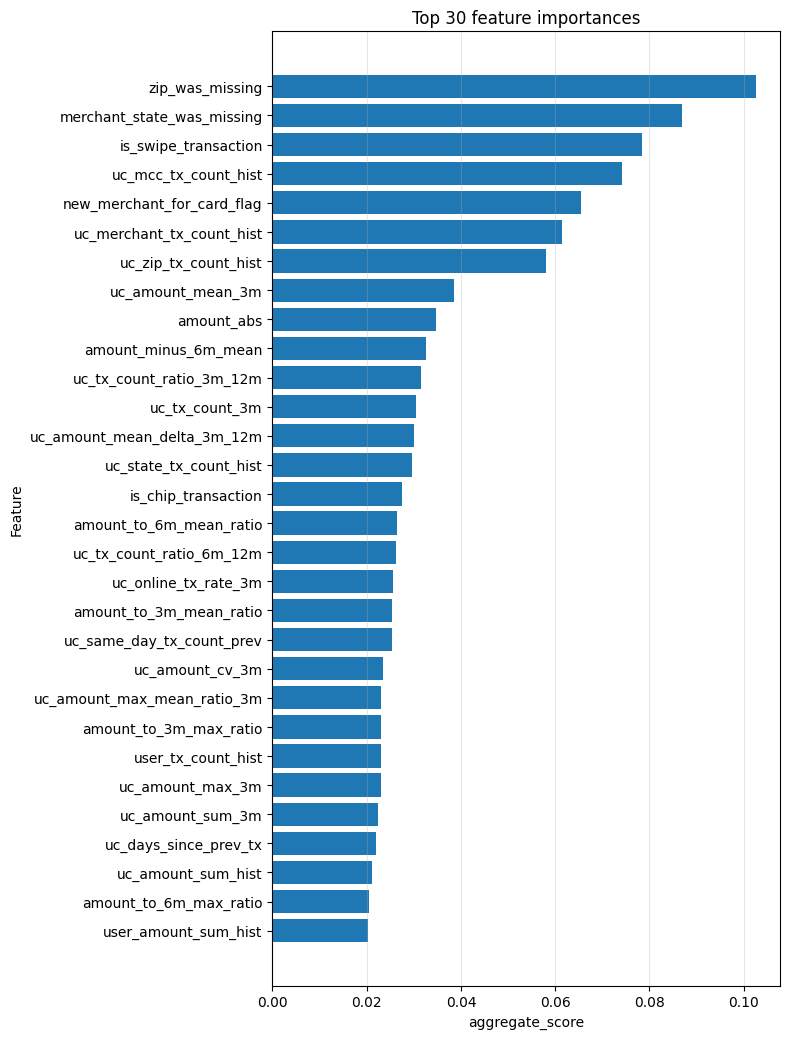

In [31]:
ranked_numeric_table = ranking_frame.loc[
    ranking_frame["feature"].isin(ranking_numeric_features),
    ["feature", "rank_average", "aggregate_score"],
].sort_values(["rank_average", "feature"])

ranked_numeric_features = ranked_numeric_table["feature"].tolist()
feature_subsets_numeric = create_feature_subsets(
    ranked_numeric_table,
    subset_sizes=RANKING_SUBSET_SIZES,
    feature_col="feature",
)

for top_n in RANKING_SUBSET_SIZES:
    selected_set = set(feature_subsets_numeric[f"top_{top_n}"])
    ranking_frame[f"selected_top_{top_n}"] = ranking_frame["feature"].isin(selected_set)

feature_ranking_csv = TABLES_DIR / "feature_ranking.csv"
feature_ranking_xlsx = TABLES_DIR / "feature_ranking.xlsx"
save_feature_ranking(ranking_frame, csv_path=feature_ranking_csv)

try:
    save_feature_ranking(ranking_frame, csv_path=feature_ranking_csv, excel_path=feature_ranking_xlsx)
except ModuleNotFoundError as exc:
    print(exc)

plot_feature_importance(
    ranking_frame=ranking_frame.dropna(subset=["aggregate_score"]),
    feature_col="feature",
    score_col="aggregate_score",
    top_n=30,
    title="Top 30 feature importances",
    output_path=FIGURES_DIR / "feature_importance_top_30.png",
)

ranking_frame.head(20)


# 13. Seleccion de subsets


In [32]:
feature_subsets = {
    subset_name: deduplicate_keep_order(feature_list + retained_categorical_features)
    for subset_name, feature_list in feature_subsets_numeric.items()
    if subset_name != "all_features"
}
feature_subsets["all_features"] = deduplicate_keep_order(ranking_numeric_features + retained_categorical_features)

subset_summary = pd.DataFrame(
    {
        "feature_subset": list(feature_subsets.keys()),
        "n_features": [len(columns) for columns in feature_subsets.values()],
        "n_numeric": [sum(column in numeric_features for column in columns) for columns in feature_subsets.values()],
        "n_categorical": [
            sum(column in categorical_features for column in columns) for columns in feature_subsets.values()
        ],
    }
)

display(subset_summary)


,feature_subset,n_features,n_numeric,n_categorical
0,top_25,25,25,0
1,top_50,50,50,0
2,top_75,75,75,0
3,top_100,100,100,0
4,all_features,157,157,0


# 14. Estrategias de entrenamiento

Se comparan cuatro familias de balanceo:
- `none`
- `class_weight_balanced` o equivalente cuando el estimador lo soporta
- `random_undersampling` con `imblearn`
- `smote` dentro del pipeline y solo sobre `train`

Las estrategias costosas se limitan a subsets pequenos o a muestras documentadas de `train` y `validation`.


# 15. Definicion de modelos y entrenamiento


In [33]:
omitted_models: list[dict[str, object]] = []
supervised_model_specs: list[dict[str, object]] = []
anomaly_model_specs: list[dict[str, object]] = []


def add_omission(model_name: str, reason: str, family: str = "supervised") -> None:
    '''Append one omitted-model record.'''

    omitted_models.append({"model_name": model_name, "model_family": family, "reason": reason})


non_negative_check_sample = sample_frame_preserving_positives(
    train_frame,
    target_column=target_col,
    max_rows=min(50_000, len(train_frame)),
    keep_all_positives=True,
)

if ranking_numeric_features:
    min_numeric_value = pd.to_numeric(
        non_negative_check_sample[ranking_numeric_features].stack(),
        errors="coerce",
    ).min()
    has_only_non_negative_features = bool(pd.notna(min_numeric_value) and min_numeric_value >= 0)
    binary_like_features = bool(
        non_negative_check_sample[ranking_numeric_features]
        .apply(lambda series: series.dropna().isin([0, 1]).all())
        .all()
    )
else:
    has_only_non_negative_features = False
    binary_like_features = False


def limit_config(model_key: str) -> dict[str, int | None]:
    return MODEL_SAMPLE_LIMITS[model_key].copy()


supervised_model_specs.extend(
    [
        {
            "model_name": "dummy_classifier",
            "model_family": "baseline",
            "balancing_strategy": "none",
            "subset_names": ["all_features"],
            "builder": lambda numeric_subset, categorical_subset: build_dummy_baseline(),
            **limit_config("dummy_classifier"),
        },
        {
            "model_name": "logistic_regression",
            "model_family": "linear",
            "balancing_strategy": "none",
            "subset_names": ["top_25", "top_50", "top_100", "all_features"],
            "builder": lambda numeric_subset, categorical_subset: build_generic_pipeline(
                LogisticRegression(
                    class_weight=None,
                    max_iter=1000,
                    random_state=RANDOM_STATE,
                    solver="liblinear",
                ),
                numeric_subset,
                categorical_subset,
                scale_numeric=True,
            ),
            **limit_config("logistic_regression"),
        },
        {
            "model_name": "logistic_regression",
            "model_family": "linear",
            "balancing_strategy": "class_weight_balanced",
            "subset_names": ["top_25", "top_50", "top_100", "all_features"],
            "builder": lambda numeric_subset, categorical_subset: build_logistic_baseline(
                numeric_subset,
                categorical_subset,
            ),
            **limit_config("logistic_regression"),
        },
        {
            "model_name": "logistic_regression",
            "model_family": "linear",
            "balancing_strategy": "random_undersampling",
            "subset_names": ["top_25", "top_50"],
            "builder": lambda numeric_subset, categorical_subset: build_random_undersample_logistic_pipeline(
                numeric_subset,
                categorical_subset,
            ),
            **limit_config("logistic_regression_undersample"),
        },
        {
            "model_name": "logistic_regression",
            "model_family": "linear",
            "balancing_strategy": "smote",
            "subset_names": ["top_25", "top_50"],
            "builder": lambda numeric_subset, categorical_subset: build_smote_logistic_pipeline(
                numeric_subset,
                categorical_subset,
            ),
            **limit_config("logistic_regression_smote"),
        },
        {
            "model_name": "decision_tree",
            "model_family": "tree",
            "balancing_strategy": "class_weight_balanced",
            "subset_names": ["top_25", "top_50", "top_100"],
            "builder": lambda numeric_subset, categorical_subset: build_decision_tree_baseline(
                numeric_subset,
                categorical_subset,
            ),
            **limit_config("decision_tree"),
        },
        {
            "model_name": "random_forest",
            "model_family": "ensemble",
            "balancing_strategy": "class_weight_balanced_subsample",
            "subset_names": ["top_25", "top_50", "top_100"],
            "builder": lambda numeric_subset, categorical_subset: build_random_forest_pipeline(
                numeric_subset,
                categorical_subset,
                n_estimators=300,
                n_jobs=1,
            ),
            **limit_config("random_forest"),
        },
        {
            "model_name": "extra_trees",
            "model_family": "ensemble",
            "balancing_strategy": "class_weight_balanced",
            "subset_names": ["top_25", "top_50", "top_100"],
            "builder": lambda numeric_subset, categorical_subset: build_generic_pipeline(
                ExtraTreesClassifier(
                    n_estimators=300,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=1,
                ),
                numeric_subset,
                categorical_subset,
                scale_numeric=False,
            ),
            **limit_config("extra_trees"),
        },
        {
            "model_name": "hist_gradient_boosting",
            "model_family": "ensemble",
            "balancing_strategy": "none",
            "subset_names": ["top_25", "top_50", "top_100"],
            "builder": lambda numeric_subset, categorical_subset: build_hist_gradient_boosting_pipeline(
                numeric_subset,
                categorical_subset,
            ),
            **limit_config("hist_gradient_boosting"),
        },
        {
            "model_name": "gradient_boosting",
            "model_family": "ensemble",
            "balancing_strategy": "none",
            "subset_names": ["top_25", "top_50"],
            "builder": lambda numeric_subset, categorical_subset: build_generic_pipeline(
                GradientBoostingClassifier(random_state=RANDOM_STATE),
                numeric_subset,
                categorical_subset,
                scale_numeric=False,
            ),
            **limit_config("gradient_boosting"),
        },
        {
            "model_name": "adaboost",
            "model_family": "ensemble",
            "balancing_strategy": "none",
            "subset_names": ["top_25", "top_50"],
            "builder": lambda numeric_subset, categorical_subset: build_generic_pipeline(
                AdaBoostClassifier(random_state=RANDOM_STATE, n_estimators=150),
                numeric_subset,
                categorical_subset,
                scale_numeric=False,
            ),
            **limit_config("adaboost"),
        },
        {
            "model_name": "bagging_tree",
            "model_family": "ensemble",
            "balancing_strategy": "none",
            "subset_names": ["top_25", "top_50"],
            "builder": lambda numeric_subset, categorical_subset: build_generic_pipeline(
                BaggingClassifier(
                    estimator=DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
                    n_estimators=50,
                    random_state=RANDOM_STATE,
                    n_jobs=1,
                ),
                numeric_subset,
                categorical_subset,
                scale_numeric=False,
            ),
            **limit_config("bagging_tree"),
        },
        {
            "model_name": "gaussian_nb",
            "model_family": "naive_bayes",
            "balancing_strategy": "none",
            "subset_names": ["top_25", "top_50", "top_100"],
            "builder": lambda numeric_subset, categorical_subset: build_generic_pipeline(
                GaussianNB(),
                numeric_subset,
                categorical_subset,
                scale_numeric=False,
            ),
            **limit_config("gaussian_nb"),
        },
        {
            "model_name": "sgd_classifier",
            "model_family": "linear_margin",
            "balancing_strategy": "class_weight_balanced",
            "subset_names": ["top_25", "top_50", "top_100", "all_features"],
            "builder": lambda numeric_subset, categorical_subset: build_generic_pipeline(
                SGDClassifier(
                    loss="log_loss",
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    max_iter=1000,
                    early_stopping=True,
                ),
                numeric_subset,
                categorical_subset,
                scale_numeric=True,
            ),
            **limit_config("sgd_classifier"),
        },
        {
            "model_name": "linear_svc",
            "model_family": "linear_margin",
            "balancing_strategy": "class_weight_balanced",
            "subset_names": ["top_25", "top_50", "top_100"],
            "builder": lambda numeric_subset, categorical_subset: build_generic_pipeline(
                LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, dual="auto"),
                numeric_subset,
                categorical_subset,
                scale_numeric=True,
            ),
            **limit_config("linear_svc"),
        },
        {
            "model_name": "mlp_classifier",
            "model_family": "neural_network",
            "balancing_strategy": "none",
            "subset_names": ["top_50", "top_100"],
            "builder": lambda numeric_subset, categorical_subset: build_generic_pipeline(
                MLPClassifier(
                    hidden_layer_sizes=(64, 32),
                    early_stopping=True,
                    max_iter=50,
                    random_state=RANDOM_STATE,
                ),
                numeric_subset,
                categorical_subset,
                scale_numeric=True,
            ),
            **limit_config("mlp_classifier"),
        },
    ]
)

if AVAILABLE_LIBRARIES["xgboost"]:
    supervised_model_specs.append(
        {
            "model_name": "xgboost",
            "model_family": "ensemble",
            "balancing_strategy": "scale_pos_weight_manual",
            "subset_names": ["top_25", "top_50", "top_100"],
            "builder": lambda numeric_subset, categorical_subset: build_generic_pipeline(
                XGBClassifier(
                    n_estimators=300,
                    max_depth=6,
                    learning_rate=0.05,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    eval_metric="logloss",
                    random_state=RANDOM_STATE,
                    n_jobs=1,
                ),
                numeric_subset,
                categorical_subset,
                scale_numeric=False,
            ),
            **limit_config("xgboost"),
        }
    )
else:
    add_omission("xgboost", "xgboost no esta instalado.")

if binary_like_features:
    supervised_model_specs.append(
        {
            "model_name": "bernoulli_nb",
            "model_family": "naive_bayes",
            "balancing_strategy": "none",
            "subset_names": ["top_25", "top_50"],
            "builder": lambda numeric_subset, categorical_subset: build_generic_pipeline(
                BernoulliNB(),
                numeric_subset,
                categorical_subset,
                scale_numeric=False,
            ),
            **limit_config("bernoulli_nb"),
        }
    )
else:
    add_omission("bernoulli_nb", "Las features no son binarias ni cercanas a Bernoulli.")

if has_only_non_negative_features:
    supervised_model_specs.append(
        {
            "model_name": "complement_nb",
            "model_family": "naive_bayes",
            "balancing_strategy": "none",
            "subset_names": ["top_25", "top_50"],
            "builder": lambda numeric_subset, categorical_subset: build_generic_pipeline(
                ComplementNB(),
                numeric_subset,
                categorical_subset,
                scale_numeric=False,
            ),
            **limit_config("complement_nb"),
        }
    )
else:
    add_omission(
        "complement_nb",
        "ComplementNB requiere features no negativas y el muestreo detecto valores negativos.",
    )

if RUN_OPTIONAL_HEAVY_MODELS:
    supervised_model_specs.extend(
        [
            {
                "model_name": "knn",
                "model_family": "neighbors",
                "balancing_strategy": "none",
                "subset_names": ["top_25", "top_50"],
                "builder": lambda numeric_subset, categorical_subset: build_generic_pipeline(
                    KNeighborsClassifier(n_neighbors=15),
                    numeric_subset,
                    categorical_subset,
                    scale_numeric=True,
                ),
                **limit_config("knn"),
            },
            {
                "model_name": "svc_rbf",
                "model_family": "kernel_margin",
                "balancing_strategy": "class_weight_balanced",
                "subset_names": ["top_25"],
                "builder": lambda numeric_subset, categorical_subset: build_generic_pipeline(
                    SVC(C=1.0, kernel="rbf", class_weight="balanced", probability=False, random_state=RANDOM_STATE),
                    numeric_subset,
                    categorical_subset,
                    scale_numeric=True,
                ),
                **limit_config("svc_rbf"),
            },
        ]
    )
else:
    add_omission("knn", "KNN omitido por defecto para no bloquear el flujo principal; habilita RUN_OPTIONAL_HEAVY_MODELS.")
    add_omission("svc_rbf", "SVC no lineal omitido por defecto para no bloquear el flujo principal; habilita RUN_OPTIONAL_HEAVY_MODELS.")

if RUN_ANOMALY_MODELS:
    anomaly_model_specs.append(
        {
            "model_name": "isolation_forest",
            "model_family": "anomaly",
            "balancing_strategy": "unsupervised_negative_train_only",
            "subset_names": ["top_25"],
            "builder": lambda: IsolationForest(
                n_estimators=300,
                contamination="auto",
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
            "scale_numeric": False,
            **limit_config("isolation_forest"),
        }
    )

    if RUN_OPTIONAL_HEAVY_MODELS:
        anomaly_model_specs.extend(
            [
                {
                    "model_name": "local_outlier_factor",
                    "model_family": "anomaly",
                    "balancing_strategy": "unsupervised_negative_train_only",
                    "subset_names": ["top_25"],
                    "builder": lambda: LocalOutlierFactor(n_neighbors=35, novelty=True),
                    "scale_numeric": True,
                    **limit_config("local_outlier_factor"),
                },
                {
                    "model_name": "one_class_svm",
                    "model_family": "anomaly",
                    "balancing_strategy": "unsupervised_negative_train_only",
                    "subset_names": ["top_25"],
                    "builder": lambda: OneClassSVM(kernel="rbf", gamma="scale", nu=0.05),
                    "scale_numeric": True,
                    **limit_config("one_class_svm"),
                },
            ]
        )
    else:
        add_omission("local_outlier_factor", "LOF omitido por defecto para no bloquear el flujo principal.", family="anomaly")
        add_omission("one_class_svm", "OneClassSVM omitido por defecto para no bloquear el flujo principal.", family="anomaly")
else:
    add_omission("isolation_forest", "Anomaly models deshabilitados por configuracion.", family="anomaly")
    add_omission("local_outlier_factor", "Anomaly models deshabilitados por configuracion.", family="anomaly")
    add_omission("one_class_svm", "Anomaly models deshabilitados por configuracion.", family="anomaly")

print(f"Supervised specs: {len(supervised_model_specs)}")
print(f"Anomaly specs: {len(anomaly_model_specs)}")


Supervised specs: 19
Anomaly specs: 3


# 16. Entrenamiento y evaluacion en validation


In [34]:
experiment_records: list[dict[str, object]] = []

for spec in supervised_model_specs:
    for subset_name in spec["subset_names"]:
        feature_subset = feature_subsets[subset_name]
        try:
            record = fit_and_evaluate_supervised_experiment(
                spec=spec,
                feature_subset_name=subset_name,
                feature_subset=feature_subset,
                split_data=split_frames,
                target_column=target_col,
            )
            experiment_records.append(record)
            print(
                f"OK | {spec['model_name']} | {subset_name} | {spec['balancing_strategy']} | PR-AUC={record['pr_auc']:.6f}"
            )
        except Exception as exc:
            add_omission(
                spec["model_name"],
                f"Fallo en entrenamiento/evaluacion para subset={subset_name}, balancing={spec['balancing_strategy']}: {exc}",
                family=str(spec["model_family"]),
            )
            print(
                f"OMITIDO | {spec['model_name']} | {subset_name} | {spec['balancing_strategy']} | razon={exc}"
            )

for spec in anomaly_model_specs:
    for subset_name in spec["subset_names"]:
        feature_subset = feature_subsets[subset_name]
        try:
            record = fit_and_evaluate_anomaly_experiment(
                spec=spec,
                feature_subset_name=subset_name,
                feature_subset=feature_subset,
                split_data=split_frames,
                target_column=target_col,
            )
            experiment_records.append(record)
            print(
                f"OK | {spec['model_name']} | {subset_name} | {spec['balancing_strategy']} | PR-AUC={record['pr_auc']:.6f}"
            )
        except Exception as exc:
            add_omission(
                spec["model_name"],
                f"Fallo en entrenamiento/evaluacion para subset={subset_name}, balancing={spec['balancing_strategy']}: {exc}",
                family=str(spec["model_family"]),
            )
            print(
                f"OMITIDO | {spec['model_name']} | {subset_name} | {spec['balancing_strategy']} | razon={exc}"
            )

results_frame = build_metrics_frame(experiment_records)
if not results_frame.empty:
    if "subset_name" in results_frame.columns:
        results_frame["feature_subset"] = results_frame["feature_subset"].fillna(results_frame["subset_name"])
        results_frame = results_frame.drop(columns=["subset_name"])
    results_frame = results_frame.sort_values(
        ["pr_auc", "recall", "f1", "precision"],
        ascending=[False, False, False, False],
    ).reset_index(drop=True)

results_frame.head(20)


OK | dummy_classifier | all_features | none | PR-AUC=0.012455
OK | logistic_regression | top_25 | none | PR-AUC=0.402182
OK | logistic_regression | top_50 | none | PR-AUC=0.432120
OK | logistic_regression | top_100 | none | PR-AUC=0.406067
OK | logistic_regression | all_features | none | PR-AUC=0.304914
OK | logistic_regression | top_25 | class_weight_balanced | PR-AUC=0.396911
OK | logistic_regression | top_50 | class_weight_balanced | PR-AUC=0.400144
OK | logistic_regression | top_100 | class_weight_balanced | PR-AUC=0.402201
OK | logistic_regression | all_features | class_weight_balanced | PR-AUC=0.371745
OK | logistic_regression | top_25 | random_undersampling | PR-AUC=0.400304
OK | logistic_regression | top_50 | random_undersampling | PR-AUC=0.397924
OK | logistic_regression | top_25 | smote | PR-AUC=0.402625
OK | logistic_regression | top_50 | smote | PR-AUC=0.398870
OK | decision_tree | top_25 | class_weight_balanced | PR-AUC=0.140441
OK | decision_tree | top_50 | class_weight_b

,threshold,n_obs,n_positive,positive_rate,precision,recall,f1,pr_auc,balanced_accuracy,roc_auc,tn,fp,fn,tp,model_name,split,feature_subset,balancing_strategy,model_family,train_time_seconds,predict_time_seconds,number_of_features_used,threshold_used,train_rows_used,validation_rows_used,classification_report_json,confusion_matrix_json,model_artifact_path,threshold_table_path,max_train_rows_requested,max_validation_rows_requested
0,0.42,40000,2491,0.062275,0.478243,0.939783,0.633902,0.701137,0.935846,0.975154,34955,2554,150,2341,svc_rbf,validation,top_25,class_weight_balanced,kernel_margin,82.550706,79.192672,25,0.42,60000,40000,"{""0"": {""precision"": 0.9957271044010825, ""recal...","[[34955, 2554], [150, 2341]]",c:\Users\cecor\OneDrive - Universidad Nacional...,c:\Users\cecor\OneDrive - Universidad Nacional...,60000.0,40000.0
1,0.41,200000,2491,0.012455,0.613975,0.578483,0.595701,0.638918,0.786948,0.989186,196603,906,1050,1441,xgboost,validation,top_100,scale_pos_weight_manual,ensemble,80.344802,27.494093,100,0.41,500000,200000,"{""0"": {""precision"": 0.9946876596864201, ""recal...","[[196603, 906], [1050, 1441]]",c:\Users\cecor\OneDrive - Universidad Nacional...,c:\Users\cecor\OneDrive - Universidad Nacional...,500000.0,200000.0
2,0.44,200000,2491,0.012455,0.557485,0.580088,0.568562,0.602019,0.787140,0.987284,196362,1147,1046,1445,xgboost,validation,top_50,scale_pos_weight_manual,ensemble,50.616569,26.981425,50,0.44,500000,200000,"{""0"": {""precision"": 0.994701329226779, ""recall...","[[196362, 1147], [1046, 1445]]",c:\Users\cecor\OneDrive - Universidad Nacional...,c:\Users\cecor\OneDrive - Universidad Nacional...,500000.0,200000.0
3,0.62,150000,2491,0.016607,0.552507,0.703332,0.618863,0.592171,0.846856,0.986827,146090,1419,739,1752,bagging_tree,validation,top_50,none,ensemble,332.898402,18.269657,50,0.62,250000,150000,"{""0"": {""precision"": 0.9949669343249631, ""recal...","[[146090, 1419], [739, 1752]]",c:\Users\cecor\OneDrive - Universidad Nacional...,c:\Users\cecor\OneDrive - Universidad Nacional...,250000.0,150000.0
4,0.52,150000,2491,0.016607,0.507414,0.686873,0.583660,0.590496,0.837806,0.985589,145848,1661,780,1711,gradient_boosting,validation,top_50,none,ensemble,535.784961,18.369181,50,0.52,250000,150000,"{""0"": {""precision"": 0.9946804157459694, ""recal...","[[145848, 1661], [780, 1711]]",c:\Users\cecor\OneDrive - Universidad Nacional...,c:\Users\cecor\OneDrive - Universidad Nacional...,250000.0,150000.0
5,0.54,200000,2491,0.012455,0.601452,0.565235,0.582781,0.587249,0.780256,0.976927,196576,933,1083,1408,mlp_classifier,validation,top_100,none,neural_network,49.286777,24.549090,100,0.54,350000,200000,"{""0"": {""precision"": 0.9945208667452532, ""recal...","[[196576, 933], [1083, 1408]]",c:\Users\cecor\OneDrive - Universidad Nacional...,c:\Users\cecor\OneDrive - Universidad Nacional...,350000.0,200000.0
6,0.62,150000,2491,0.016607,0.573562,0.632276,0.601489,0.585080,0.812169,0.985841,146338,1171,916,1575,bagging_tree,validation,top_25,none,ensemble,146.250922,16.477492,25,0.62,250000,150000,"{""0"": {""precision"": 0.9937794559061214, ""recal...","[[146338, 1171], [916, 1575]]",c:\Users\cecor\OneDrive - Universidad Nacional...,c:\Users\cecor\OneDrive - Universidad Nacional...,250000.0,150000.0
7,0.54,60000,2491,0.041517,0.526225,0.737053,0.614047,0.578760,0.854155,0.968479,55856,1653,655,1836,knn,validation,top_25,none,neighbors,0.426549,18.911502,25,0.54,120000,60000,"{""0"": {""precision"": 0.9884093362354232, ""recal...","[[55856, 1653], [655, 1836]]",c:\Users\cecor\OneDrive - Universidad Nacional...,c:\Users\cecor\OneDrive - Universidad Nacional...,120000.0,60000.0
8,0.57,150000,2491,0.016607,0.504750,0.639904,0.564348,0.559102,0.814650,0.984573,145945,1564,897,1594,gradient_boosting,validation,top_25,none,ensemble,237.823462,17.520861,25,0.57,250000,150000,"{""0"": {""precision"": 0.9938913934705329, ""recal...","[[145945, 1564], [897, 1594]]",c:\Users\cecor\OneDrive - Universidad Nacional...,c:\Users\ce

# 17. Guardado de metricas


In [35]:
model_results_csv = TABLES_DIR / "model_experiment_results.csv"
model_results_xlsx = TABLES_DIR / "model_experiment_results.xlsx"

if results_frame.empty:
    print("No hay resultados para guardar.")
else:
    save_metrics_table(results_frame, csv_path=model_results_csv)
    try:
        save_metrics_table(results_frame, csv_path=model_results_csv, excel_path=model_results_xlsx)
    except ModuleNotFoundError as exc:
        print(exc)

omitted_models_frame = pd.DataFrame(omitted_models)
if not omitted_models_frame.empty:
    omitted_models_frame.to_csv(TABLES_DIR / "omitted_model_experiments.csv", index=False)

results_frame.head(10)


,threshold,n_obs,n_positive,positive_rate,precision,recall,f1,pr_auc,balanced_accuracy,roc_auc,tn,fp,fn,tp,model_name,split,feature_subset,balancing_strategy,model_family,train_time_seconds,predict_time_seconds,number_of_features_used,threshold_used,train_rows_used,validation_rows_used,classification_report_json,confusion_matrix_json,model_artifact_path,threshold_table_path,max_train_rows_requested,max_validation_rows_requested
0,0.42,40000,2491,0.062275,0.478243,0.939783,0.633902,0.701137,0.935846,0.975154,34955,2554,150,2341,svc_rbf,validation,top_25,class_weight_balanced,kernel_margin,82.550706,79.192672,25,0.42,60000,40000,"{""0"": {""precision"": 0.9957271044010825, ""recal...","[[34955, 2554], [150, 2341]]",c:\Users\cecor\OneDrive - Universidad Nacional...,c:\Users\cecor\OneDrive - Universidad Nacional...,60000.0,40000.0
1,0.41,200000,2491,0.012455,0.613975,0.578483,0.595701,0.638918,0.786948,0.989186,196603,906,1050,1441,xgboost,validation,top_100,scale_pos_weight_manual,ensemble,80.344802,27.494093,100,0.41,500000,200000,"{""0"": {""precision"": 0.9946876596864201, ""recal...","[[196603, 906], [1050, 1441]]",c:\Users\cecor\OneDrive - Universidad Nacional...,c:\Users\cecor\OneDrive - Universidad Nacional...,500000.0,200000.0
2,0.44,200000,2491,0.012455,0.557485,0.580088,0.568562,0.602019,0.787140,0.987284,196362,1147,1046,1445,xgboost,validation,top_50,scale_pos_weight_manual,ensemble,50.616569,26.981425,50,0.44,500000,200000,"{""0"": {""precision"": 0.994701329226779, ""recall...","[[196362, 1147], [1046, 1445]]",c:\Users\cecor\OneDrive - Universidad Nacional...,c:\Users\cecor\OneDrive - Universidad Nacional...,500000.0,200000.0
3,0.62,150000,2491,0.016607,0.552507,0.703332,0.618863,0.592171,0.846856,0.986827,146090,1419,739,1752,bagging_tree,validation,top_50,none,ensemble,332.898402,18.269657,50,0.62,250000,150000,"{""0"": {""precision"": 0.9949669343249631, ""recal...","[[146090, 1419], [739, 1752]]",c:\Users\cecor\OneDrive - Universidad Nacional...,c:\Users\cecor\OneDrive - Universidad Nacional...,250000.0,150000.0
4,0.52,150000,2491,0.016607,0.507414,0.686873,0.583660,0.590496,0.837806,0.985589,145848,1661,780,1711,gradient_boosting,validation,top_50,none,ensemble,535.784961,18.369181,50,0.52,250000,150000,"{""0"": {""precision"": 0.9946804157459694, ""recal...","[[145848, 1661], [780, 1711]]",c:\Users\cecor\OneDrive - Universidad Nacional...,c:\Users\cecor\OneDrive - Universidad Nacional...,250000.0,150000.0
5,0.54,200000,2491,0.012455,0.601452,0.565235,0.582781,0.587249,0.780256,0.976927,196576,933,1083,1408,mlp_classifier,validation,top_100,none,neural_network,49.286777,24.549090,100,0.54,350000,200000,"{""0"": {""precision"": 0.9945208667452532, ""recal...","[[196576, 933], [1083, 1408]]",c:\Users\cecor\OneDrive - Universidad Nacional...,c:\Users\cecor\OneDrive - Universidad Nacional...,350000.0,200000.0
6,0.62,150000,2491,0.016607,0.573562,0.632276,0.601489,0.585080,0.812169,0.985841,146338,1171,916,1575,bagging_tree,validation,top_25,none,ensemble,146.250922,16.477492,25,0.62,250000,150000,"{""0"": {""precision"": 0.9937794559061214, ""recal...","[[146338, 1171], [916, 1575]]",c:\Users\cecor\OneDrive - Universidad Nacional...,c:\Users\cecor\OneDrive - Universidad Nacional...,250000.0,150000.0
7,0.54,60000,2491,0.041517,0.526225,0.737053,0.614047,0.578760,0.854155,0.968479,55856,1653,655,1836,knn,validation,top_25,none,neighbors,0.426549,18.911502,25,0.54,120000,60000,"{""0"": {""precision"": 0.9884093362354232, ""recal...","[[55856, 1653], [655, 1836]]",c:\Users\cecor\OneDrive - Universidad Nacional...,c:\Users\cecor\OneDrive - Universidad Nacional...,120000.0,60000.0
8,0.57,150000,2491,0.016607,0.504750,0.639904,0.564348,0.559102,0.814650,0.984573,145945,1564,897,1594,gradient_boosting,validation,top_25,none,ensemble,237.823462,17.520861,25,0.57,250000,150000,"{""0"": {""precision"": 0.9938913934705329, ""recal...","[[145945, 1564], [897, 1594]]",c:\Users\cecor\OneDrive - Universidad Nacional...,c:\Users\ce

# 18. Guardado de figuras


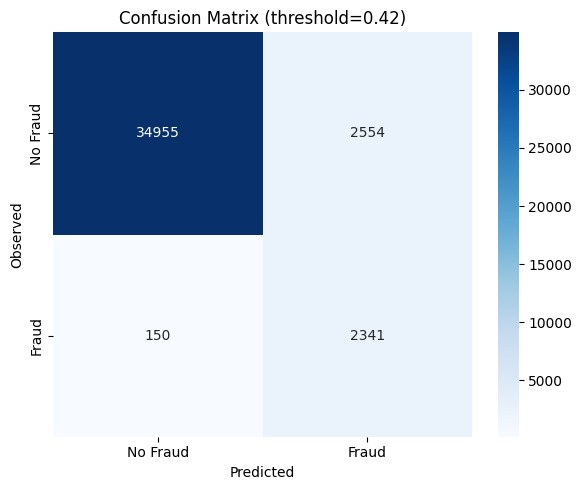

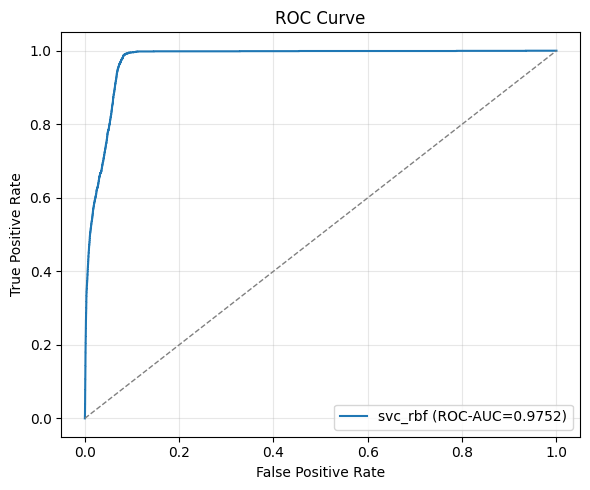

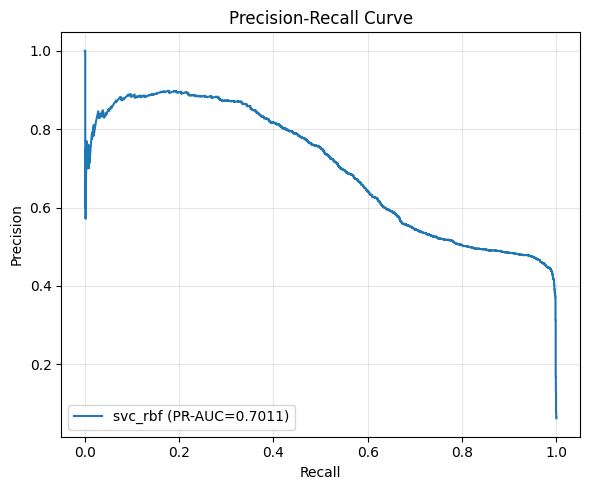

In [36]:
if not results_frame.empty:
    plot_metric_comparison(results_frame, "pr_auc", FIGURES_DIR / "model_pr_auc_comparison.png")
    plot_metric_comparison(results_frame, "roc_auc", FIGURES_DIR / "model_roc_auc_comparison.png")
    plot_metric_comparison(results_frame, "recall", FIGURES_DIR / "model_recall_comparison.png")
    plot_metric_comparison(results_frame, "f1", FIGURES_DIR / "model_f1_comparison.png")

    best_row = results_frame.iloc[0]
    best_artifact = joblib.load(best_row["model_artifact_path"])
    best_feature_subset = best_artifact["feature_columns"]
    max_validation_rows = best_artifact.get("max_validation_rows")
    validation_sample_for_best = sample_frame_preserving_positives(
        validation_frame,
        target_column=target_col,
        max_rows=max_validation_rows,
        keep_all_positives=True,
    )
    x_validation_best, y_validation_best = split_features_target(
        validation_sample_for_best,
        target_col=target_col,
        feature_cols=best_feature_subset,
    )

    if best_artifact.get("experiment_family") == "anomaly":
        transformed_validation = best_artifact["preprocessor"].transform(x_validation_best)
        best_scores = get_anomaly_scores(best_artifact["model"], transformed_validation)
    else:
        best_scores = get_positive_class_scores(best_artifact["model"], x_validation_best)

    plot_confusion_matrix(
        y_validation_best,
        best_scores,
        threshold=best_artifact["threshold"],
        output_path=FIGURES_DIR / "best_validation_confusion_matrix.png",
    )
    plot_roc_curve(
        y_validation_best,
        best_scores,
        model_name=str(best_row["model_name"]),
        output_path=FIGURES_DIR / "best_validation_roc_curve.png",
    )
    plot_precision_recall_curve(
        y_validation_best,
        best_scores,
        model_name=str(best_row["model_name"]),
        output_path=FIGURES_DIR / "best_validation_precision_recall_curve.png",
    )
else:
    print("No se generaron figuras porque no hay resultados de experimentos.")


# 19. Experimentos opcionales separados: GAN/CTGAN y deep learning


In [37]:
optional_experiment_records: list[dict[str, object]] = []
optional_comparison_rows: list[dict[str, object]] = []


def _refresh_results_outputs() -> None:
    global results_frame

    if results_frame.empty:
        print("No hay resultados para actualizar.")
        return

    results_frame = results_frame.sort_values(
        ["pr_auc", "recall", "f1", "precision"],
        ascending=[False, False, False, False],
    ).reset_index(drop=True)

    save_metrics_table(results_frame, csv_path=model_results_csv)
    try:
        save_metrics_table(results_frame, csv_path=model_results_csv, excel_path=model_results_xlsx)
    except ModuleNotFoundError as exc:
        print(exc)

    omitted_models_frame = pd.DataFrame(omitted_models)
    if not omitted_models_frame.empty:
        omitted_models_frame.to_csv(TABLES_DIR / "omitted_model_experiments.csv", index=False)

    plot_metric_comparison(results_frame, "pr_auc", FIGURES_DIR / "model_pr_auc_comparison.png")
    plot_metric_comparison(results_frame, "roc_auc", FIGURES_DIR / "model_roc_auc_comparison.png")
    plot_metric_comparison(results_frame, "recall", FIGURES_DIR / "model_recall_comparison.png")
    plot_metric_comparison(results_frame, "f1", FIGURES_DIR / "model_f1_comparison.png")


def _build_optional_record(
    model_name: str,
    model_family: str,
    balancing_strategy: str,
    feature_subset_name: str,
    feature_subset: list[str],
    y_validation: pd.Series,
    scores: pd.Series,
    threshold_used: float,
    train_rows_used: int,
    validation_rows_used: int,
    train_time_seconds: float,
    predict_time_seconds: float,
    artifact_path: Path,
    classification_report_json: str,
) -> dict[str, object]:
    metrics = compute_classification_metrics(y_validation, scores, threshold=threshold_used)
    metrics.update(
        {
            "model_name": model_name,
            "split": "validation",
            "feature_subset": feature_subset_name,
            "balancing_strategy": balancing_strategy,
            "model_family": model_family,
            "train_time_seconds": train_time_seconds,
            "predict_time_seconds": predict_time_seconds,
            "number_of_features_used": len(feature_subset),
            "threshold_used": threshold_used,
            "train_rows_used": int(train_rows_used),
            "validation_rows_used": int(validation_rows_used),
            "classification_report_json": classification_report_json,
            "confusion_matrix_json": json.dumps(
                [[metrics["tn"], metrics["fp"]], [metrics["fn"], metrics["tp"]]]
            ),
            "model_artifact_path": str(artifact_path),
        }
    )
    return metrics


def _save_thresholds_for_optional(
    model_name: str,
    subset_name: str,
    balancing_strategy: str,
    threshold_table: pd.DataFrame,
) -> None:
    threshold_path = METRICS_DIR / (
        build_model_filename(model_name, subset_name, balancing_strategy).replace(".joblib", "_thresholds.csv")
    )
    save_threshold_table(threshold_table, csv_path=threshold_path)


def _append_optional_result(
    model_name: str,
    model_family: str,
    balancing_strategy: str,
    feature_subset_name: str,
    feature_subset: list[str],
    y_validation: pd.Series,
    scores: pd.Series,
    threshold_result,
    train_rows_used: int,
    validation_rows_used: int,
    train_time_seconds: float,
    predict_time_seconds: float,
    artifact_path: Path,
) -> dict[str, object]:
    y_pred = get_predicted_labels(scores, threshold=threshold_result.threshold)
    record = _build_optional_record(
        model_name=model_name,
        model_family=model_family,
        balancing_strategy=balancing_strategy,
        feature_subset_name=feature_subset_name,
        feature_subset=feature_subset,
        y_validation=y_validation,
        scores=scores,
        threshold_used=float(threshold_result.threshold),
        train_rows_used=train_rows_used,
        validation_rows_used=validation_rows_used,
        train_time_seconds=train_time_seconds,
        predict_time_seconds=predict_time_seconds,
        artifact_path=artifact_path,
        classification_report_json=json.dumps(
            classification_report(y_validation, y_pred, output_dict=True, zero_division=0),
            default=float,
        ),
    )
    optional_experiment_records.append(record)
    return record


def _artifact_path(model_name: str, subset_name: str, balancing_strategy: str, extension: str = ".joblib") -> Path:
    base_name = build_model_filename(model_name, subset_name, balancing_strategy).replace(".joblib", extension)
    return MODELS_DIR / base_name


if RUN_GAN_EXPERIMENT and AVAILABLE_LIBRARIES["ctgan"]:
    from ctgan import CTGAN
    from sklearn.impute import SimpleImputer
    from sklearn.pipeline import Pipeline as SklearnPipeline
    from sklearn.preprocessing import StandardScaler

    ctgan_subset_name = "top_50" if "top_50" in feature_subsets else next(iter(feature_subsets))
    ctgan_feature_subset = [col for col in feature_subsets[ctgan_subset_name] if col in numeric_features]

    if len(ctgan_feature_subset) < 5:
        add_omission(
            "ctgan_logistic_regression",
            "CTGAN omitido: no hay suficientes features numericas en el subset seleccionado.",
            family="synthetic_generation",
        )
        print("CTGAN omitido: subset numerico insuficiente.")
    else:
        ctgan_train_sample = sample_frame_preserving_positives(
            train_frame,
            target_column=target_col,
            max_rows=CTGAN_MAX_TRAIN_ROWS,
            keep_all_positives=True,
        )
        ctgan_validation_sample = sample_frame_preserving_positives(
            validation_frame,
            target_column=target_col,
            max_rows=CTGAN_MAX_VALIDATION_ROWS,
            keep_all_positives=True,
        )
        positive_train = ctgan_train_sample.loc[ctgan_train_sample[target_col] == 1, ctgan_feature_subset]
        if len(positive_train) > CTGAN_POSITIVE_TRAIN_CAP:
            positive_train = positive_train.sample(n=CTGAN_POSITIVE_TRAIN_CAP, random_state=RANDOM_STATE)

        x_ctgan_train = ctgan_train_sample.loc[:, ctgan_feature_subset].copy()
        y_ctgan_train = ctgan_train_sample[target_col].copy()
        x_ctgan_validation = ctgan_validation_sample.loc[:, ctgan_feature_subset].copy()
        y_ctgan_validation = ctgan_validation_sample[target_col].copy()

        imputer = SimpleImputer(strategy="median")
        x_train_imputed = pd.DataFrame(
            imputer.fit_transform(x_ctgan_train), columns=ctgan_feature_subset, index=x_ctgan_train.index
        )
        x_validation_imputed = pd.DataFrame(
            imputer.transform(x_ctgan_validation), columns=ctgan_feature_subset, index=x_ctgan_validation.index
        )

        baseline_fit_start = time.perf_counter()
        gan_reference_classifier = SklearnPipeline(
            steps=[
                ("scaler", StandardScaler()),
                (
                    "estimator",
                    LogisticRegression(
                        max_iter=1000,
                        random_state=RANDOM_STATE,
                        solver="liblinear",
                    ),
                ),
            ]
        )
        gan_reference_classifier.fit(x_train_imputed, y_ctgan_train)
        baseline_train_time = time.perf_counter() - baseline_fit_start

        baseline_predict_start = time.perf_counter()
        gan_reference_scores = pd.Series(
            gan_reference_classifier.predict_proba(x_validation_imputed)[:, 1],
            index=y_ctgan_validation.index,
            name="score",
        )
        gan_reference_threshold_table = build_threshold_table(y_ctgan_validation, gan_reference_scores)
        gan_reference_threshold_result = select_threshold(
            gan_reference_threshold_table,
            criterion=THRESHOLD_CRITERION,
        )
        baseline_predict_time = time.perf_counter() - baseline_predict_start

        gan_reference_artifact_path = _artifact_path(
            "logistic_regression_gan_reference",
            ctgan_subset_name,
            "none",
        )
        joblib.dump(
            {
                "classifier": gan_reference_classifier,
                "imputer": imputer,
                "feature_columns": ctgan_feature_subset,
                "threshold": float(gan_reference_threshold_result.threshold),
                "model_name": "logistic_regression_gan_reference",
                "balancing_strategy": "none",
                "feature_subset": ctgan_subset_name,
                "experiment_family": "synthetic_generation_reference",
            },
            gan_reference_artifact_path,
        )
        _save_thresholds_for_optional(
            "logistic_regression_gan_reference",
            ctgan_subset_name,
            "none",
            gan_reference_threshold_result.threshold_table,
        )
        gan_reference_record = _append_optional_result(
            model_name="logistic_regression_gan_reference",
            model_family="synthetic_generation_reference",
            balancing_strategy="none",
            feature_subset_name=ctgan_subset_name,
            feature_subset=ctgan_feature_subset,
            y_validation=y_ctgan_validation,
            scores=gan_reference_scores,
            threshold_result=gan_reference_threshold_result,
            train_rows_used=int(len(x_train_imputed)),
            validation_rows_used=int(len(x_validation_imputed)),
            train_time_seconds=baseline_train_time,
            predict_time_seconds=baseline_predict_time,
            artifact_path=gan_reference_artifact_path,
        )
        print(
            f"OK | logistic_regression_gan_reference | {ctgan_subset_name} | none | PR-AUC={gan_reference_record['pr_auc']:.6f}"
        )

        if len(positive_train) < 100:
            add_omission(
                "ctgan_logistic_regression",
                f"CTGAN omitido: solo {len(positive_train)} fraudes disponibles en train_sample.",
                family="synthetic_generation",
            )
            print("CTGAN omitido por pocos positivos en train_sample.")
        else:
            positive_imputed = x_train_imputed.loc[y_ctgan_train == 1].copy()
            synthetic_rows = min(CTGAN_MAX_SYNTHETIC_ROWS, len(positive_imputed) * CTGAN_SYNTHETIC_MULTIPLIER)

            fit_start = time.perf_counter()
            ctgan_model = CTGAN(epochs=20, verbose=False)
            ctgan_model.fit(positive_imputed)
            synthetic_positive = ctgan_model.sample(synthetic_rows)
            synthetic_positive = synthetic_positive.loc[:, ctgan_feature_subset].astype(np.float32)

            augmented_x_train = pd.concat([x_train_imputed, synthetic_positive], axis=0, ignore_index=True)
            augmented_y_train = pd.concat(
                [y_ctgan_train.reset_index(drop=True), pd.Series(np.ones(len(synthetic_positive), dtype=int))],
                axis=0,
                ignore_index=True,
            )

            ctgan_classifier = SklearnPipeline(
                steps=[
                    ("scaler", StandardScaler()),
                    (
                        "estimator",
                        LogisticRegression(
                            max_iter=1000,
                            random_state=RANDOM_STATE,
                            solver="liblinear",
                        ),
                    ),
                ]
            )
            ctgan_classifier.fit(augmented_x_train, augmented_y_train)
            train_time_seconds = time.perf_counter() - fit_start

            predict_start = time.perf_counter()
            ctgan_scores = pd.Series(
                ctgan_classifier.predict_proba(x_validation_imputed)[:, 1],
                index=y_ctgan_validation.index,
                name="score",
            )
            ctgan_threshold_table = build_threshold_table(y_ctgan_validation, ctgan_scores)
            ctgan_threshold_result = select_threshold(ctgan_threshold_table, criterion=THRESHOLD_CRITERION)
            predict_time_seconds = time.perf_counter() - predict_start

            ctgan_artifact_path = _artifact_path(
                "ctgan_logistic_regression",
                ctgan_subset_name,
                "synthetic",
            )
            joblib.dump(
                {
                    "ctgan_model": ctgan_model,
                    "classifier": ctgan_classifier,
                    "imputer": imputer,
                    "feature_columns": ctgan_feature_subset,
                    "threshold": float(ctgan_threshold_result.threshold),
                    "model_name": "ctgan_logistic_regression",
                    "balancing_strategy": "ctgan_synthetic",
                    "feature_subset": ctgan_subset_name,
                    "experiment_family": "synthetic_generation",
                },
                ctgan_artifact_path,
            )
            _save_thresholds_for_optional(
                "ctgan_logistic_regression",
                ctgan_subset_name,
                "ctgan_synthetic",
                ctgan_threshold_result.threshold_table,
            )
            ctgan_record = _append_optional_result(
                model_name="ctgan_logistic_regression",
                model_family="synthetic_generation",
                balancing_strategy="ctgan_synthetic",
                feature_subset_name=ctgan_subset_name,
                feature_subset=ctgan_feature_subset,
                y_validation=y_ctgan_validation,
                scores=ctgan_scores,
                threshold_result=ctgan_threshold_result,
                train_rows_used=int(len(augmented_x_train)),
                validation_rows_used=int(len(x_validation_imputed)),
                train_time_seconds=train_time_seconds,
                predict_time_seconds=predict_time_seconds,
                artifact_path=ctgan_artifact_path,
            )
            print(f"OK | ctgan_logistic_regression | {ctgan_subset_name} | ctgan_synthetic | PR-AUC={ctgan_record['pr_auc']:.6f}")

            optional_comparison_rows.append(
                {
                    "comparison_group": "gan_vs_no_gan",
                    "feature_subset": ctgan_subset_name,
                    "baseline_model": "logistic_regression_gan_reference",
                    "treatment_model": "ctgan_logistic_regression",
                    "baseline_pr_auc": gan_reference_record["pr_auc"],
                    "treatment_pr_auc": ctgan_record["pr_auc"],
                    "delta_pr_auc": ctgan_record["pr_auc"] - gan_reference_record["pr_auc"],
                    "baseline_recall": gan_reference_record["recall"],
                    "treatment_recall": ctgan_record["recall"],
                    "delta_recall": ctgan_record["recall"] - gan_reference_record["recall"],
                    "baseline_f1": gan_reference_record["f1"],
                    "treatment_f1": ctgan_record["f1"],
                    "delta_f1": ctgan_record["f1"] - gan_reference_record["f1"],
                    "train_rows_reference": int(len(x_train_imputed)),
                    "train_rows_treatment": int(len(augmented_x_train)),
                    "validation_rows": int(len(x_validation_imputed)),
                }
            )
            print(
                "Comparacion GAN vs no GAN | "
                f"delta PR-AUC={ctgan_record['pr_auc'] - gan_reference_record['pr_auc']:.6f} | "
                f"delta recall={ctgan_record['recall'] - gan_reference_record['recall']:.6f}"
            )
else:
    add_omission(
        "ctgan_logistic_regression",
        "CTGAN omitido: dependencia no instalada o flag deshabilitado.",
        family="synthetic_generation",
    )
    add_omission(
        "logistic_regression_gan_reference",
        "Referencia sin GAN omitida porque el experimento CTGAN no se habilito.",
        family="synthetic_generation_reference",
    )
    print("CTGAN omitido del flujo principal.")


if RUN_DEEP_LEARNING_EXPERIMENTS and AVAILABLE_LIBRARIES["torch"]:
    import torch
    import torch.nn as nn
    from sklearn.calibration import CalibratedClassifierCV
    from torch.utils.data import DataLoader, TensorDataset

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    class FraudMLP(nn.Module):
        def __init__(self, input_dim: int):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(input_dim, 128),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(64, 1),
            )

        def forward(self, x):
            return self.net(x).squeeze(1)

    class FraudAutoencoder(nn.Module):
        def __init__(self, input_dim: int):
            super().__init__()
            hidden = max(16, min(128, input_dim // 2 if input_dim >= 4 else 16))
            bottleneck = max(8, min(64, hidden // 2))
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, hidden),
                nn.ReLU(),
                nn.Linear(hidden, bottleneck),
                nn.ReLU(),
            )
            self.decoder = nn.Sequential(
                nn.Linear(bottleneck, hidden),
                nn.ReLU(),
                nn.Linear(hidden, input_dim),
            )

        def forward(self, x):
            z = self.encoder(x)
            return self.decoder(z)

    def _as_float32_dense(array_like) -> np.ndarray:
        return np.asarray(array_like, dtype=np.float32)

    def _fit_torch_binary_mlp(x_train: np.ndarray, y_train: np.ndarray, x_val: np.ndarray, y_val: np.ndarray):
        model = FraudMLP(x_train.shape[1]).to(device)
        positives = max(float(y_train.sum()), 1.0)
        negatives = max(float((1 - y_train).sum()), 1.0)
        pos_weight = torch.tensor([negatives / positives], dtype=torch.float32, device=device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        optimizer = torch.optim.Adam(model.parameters(), lr=TORCH_MLP_LR)

        train_dataset = TensorDataset(
            torch.tensor(x_train, dtype=torch.float32),
            torch.tensor(y_train, dtype=torch.float32),
        )
        train_loader = DataLoader(train_dataset, batch_size=TORCH_MLP_BATCH_SIZE, shuffle=True)

        best_state = None
        best_val_loss = float("inf")
        patience_counter = 0

        for _ in range(TORCH_MLP_EPOCHS):
            model.train()
            for xb, yb in train_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                optimizer.zero_grad()
                logits = model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()

            model.eval()
            with torch.no_grad():
                val_logits = model(torch.tensor(x_val, dtype=torch.float32, device=device))
                val_loss = criterion(val_logits, torch.tensor(y_val, dtype=torch.float32, device=device)).item()

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= TORCH_MLP_PATIENCE:
                    break

        if best_state is not None:
            model.load_state_dict(best_state)
        return model

    def _fit_torch_autoencoder(x_train_negative: np.ndarray, x_val_reference: np.ndarray):
        model = FraudAutoencoder(x_train_negative.shape[1]).to(device)
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=AUTOENCODER_LR)

        train_dataset = TensorDataset(torch.tensor(x_train_negative, dtype=torch.float32))
        train_loader = DataLoader(train_dataset, batch_size=AUTOENCODER_BATCH_SIZE, shuffle=True)
        val_tensor = torch.tensor(x_val_reference, dtype=torch.float32, device=device)

        best_state = None
        best_val_loss = float("inf")
        patience_counter = 0

        for _ in range(AUTOENCODER_EPOCHS):
            model.train()
            for (xb,) in train_loader:
                xb = xb.to(device)
                optimizer.zero_grad()
                recon = model(xb)
                loss = criterion(recon, xb)
                loss.backward()
                optimizer.step()

            model.eval()
            with torch.no_grad():
                val_recon = model(val_tensor)
                val_loss = ((val_recon - val_tensor) ** 2).mean().item()

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= AUTOENCODER_PATIENCE:
                    break

        if best_state is not None:
            model.load_state_dict(best_state)
        return model

    mlp_subset_name = "top_100" if "top_100" in feature_subsets else ("top_50" if "top_50" in feature_subsets else next(iter(feature_subsets)))
    mlp_feature_subset = feature_subsets[mlp_subset_name]
    mlp_numeric_subset = [column for column in mlp_feature_subset if column in numeric_features]
    mlp_categorical_subset = [column for column in mlp_feature_subset if column in categorical_features]

    if AVAILABLE_LIBRARIES["xgboost"]:
        xgb_train_sample = sample_frame_preserving_positives(
            train_frame,
            target_column=target_col,
            max_rows=XGB_CALIBRATED_MAX_TRAIN_ROWS,
            keep_all_positives=True,
        )
        xgb_validation_sample = sample_frame_preserving_positives(
            validation_frame,
            target_column=target_col,
            max_rows=XGB_CALIBRATED_MAX_VALIDATION_ROWS,
            keep_all_positives=True,
        )
        x_train_xgb, y_train_xgb = split_features_target(xgb_train_sample, target_col=target_col, feature_cols=mlp_feature_subset)
        x_validation_xgb, y_validation_xgb = split_features_target(
            xgb_validation_sample,
            target_col=target_col,
            feature_cols=mlp_feature_subset,
        )
        positives = max(float(y_train_xgb.sum()), 1.0)
        negatives = max(float((y_train_xgb == 0).sum()), 1.0)
        scale_pos_weight = negatives / positives
        xgb_pipeline = build_generic_pipeline(
            XGBClassifier(
                n_estimators=250,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=1,
                scale_pos_weight=scale_pos_weight,
            ),
            mlp_numeric_subset,
            mlp_categorical_subset,
            scale_numeric=False,
        )
        calibrated_xgb = CalibratedClassifierCV(
            estimator=xgb_pipeline,
            method="sigmoid",
            cv=XGB_CALIBRATED_CV,
        )
        fit_start = time.perf_counter()
        calibrated_xgb.fit(x_train_xgb, y_train_xgb)
        xgb_train_time = time.perf_counter() - fit_start

        predict_start = time.perf_counter()
        xgb_scores = pd.Series(
            calibrated_xgb.predict_proba(x_validation_xgb)[:, 1],
            index=y_validation_xgb.index,
            name="score",
        )
        xgb_threshold_table = build_threshold_table(y_validation_xgb, xgb_scores)
        xgb_threshold_result = select_threshold(xgb_threshold_table, criterion=THRESHOLD_CRITERION)
        xgb_predict_time = time.perf_counter() - predict_start

        xgb_artifact_path = _artifact_path("xgboost_calibrated", mlp_subset_name, "scale_pos_weight")
        joblib.dump(
            {
                "model": calibrated_xgb,
                "feature_columns": mlp_feature_subset,
                "numeric_features": mlp_numeric_subset,
                "categorical_features": mlp_categorical_subset,
                "threshold": float(xgb_threshold_result.threshold),
                "model_name": "xgboost_calibrated",
                "balancing_strategy": "scale_pos_weight",
                "feature_subset": mlp_subset_name,
                "experiment_family": "ensemble_calibrated",
            },
            xgb_artifact_path,
        )
        _save_thresholds_for_optional("xgboost_calibrated", mlp_subset_name, "scale_pos_weight", xgb_threshold_result.threshold_table)
        xgb_record = _append_optional_result(
            model_name="xgboost_calibrated",
            model_family="ensemble_calibrated",
            balancing_strategy="scale_pos_weight",
            feature_subset_name=mlp_subset_name,
            feature_subset=mlp_feature_subset,
            y_validation=y_validation_xgb,
            scores=xgb_scores,
            threshold_result=xgb_threshold_result,
            train_rows_used=int(len(xgb_train_sample)),
            validation_rows_used=int(len(xgb_validation_sample)),
            train_time_seconds=xgb_train_time,
            predict_time_seconds=xgb_predict_time,
            artifact_path=xgb_artifact_path,
        )
        print(f"OK | xgboost_calibrated | {mlp_subset_name} | scale_pos_weight | PR-AUC={xgb_record['pr_auc']:.6f}")
    else:
        add_omission(
            "xgboost_calibrated",
            "XGBoost calibrado omitido: xgboost no esta instalado.",
            family="ensemble_calibrated",
        )

    light_mlp_train_sample = sample_frame_preserving_positives(
        train_frame,
        target_column=target_col,
        max_rows=LIGHT_MLP_MAX_TRAIN_ROWS,
        keep_all_positives=True,
    )
    light_mlp_validation_sample = sample_frame_preserving_positives(
        validation_frame,
        target_column=target_col,
        max_rows=LIGHT_MLP_MAX_VALIDATION_ROWS,
        keep_all_positives=True,
    )
    x_train_light_mlp, y_train_light_mlp = split_features_target(
        light_mlp_train_sample,
        target_col=target_col,
        feature_cols=mlp_feature_subset,
    )
    x_validation_light_mlp, y_validation_light_mlp = split_features_target(
        light_mlp_validation_sample,
        target_col=target_col,
        feature_cols=mlp_feature_subset,
    )
    light_mlp_model = build_generic_pipeline(
        MLPClassifier(
            hidden_layer_sizes=LIGHT_MLP_HIDDEN_LAYERS,
            early_stopping=True,
            max_iter=LIGHT_MLP_MAX_ITER,
            random_state=RANDOM_STATE,
        ),
        mlp_numeric_subset,
        mlp_categorical_subset,
        scale_numeric=True,
    )
    fit_start = time.perf_counter()
    light_mlp_model.fit(x_train_light_mlp, y_train_light_mlp)
    light_mlp_train_time = time.perf_counter() - fit_start

    predict_start = time.perf_counter()
    light_mlp_scores = pd.Series(
        light_mlp_model.predict_proba(x_validation_light_mlp)[:, 1],
        index=y_validation_light_mlp.index,
        name="score",
    )
    light_mlp_threshold_table = build_threshold_table(y_validation_light_mlp, light_mlp_scores)
    light_mlp_threshold_result = select_threshold(light_mlp_threshold_table, criterion=THRESHOLD_CRITERION)
    light_mlp_predict_time = time.perf_counter() - predict_start

    light_mlp_artifact_path = _artifact_path("mlp_classifier_light", mlp_subset_name, "none")
    joblib.dump(
        {
            "model": light_mlp_model,
            "feature_columns": mlp_feature_subset,
            "numeric_features": mlp_numeric_subset,
            "categorical_features": mlp_categorical_subset,
            "threshold": float(light_mlp_threshold_result.threshold),
            "model_name": "mlp_classifier_light",
            "balancing_strategy": "none",
            "feature_subset": mlp_subset_name,
            "experiment_family": "neural_network_reference",
        },
        light_mlp_artifact_path,
    )
    _save_thresholds_for_optional("mlp_classifier_light", mlp_subset_name, "none", light_mlp_threshold_result.threshold_table)
    light_mlp_record = _append_optional_result(
        model_name="mlp_classifier_light",
        model_family="neural_network_reference",
        balancing_strategy="none",
        feature_subset_name=mlp_subset_name,
        feature_subset=mlp_feature_subset,
        y_validation=y_validation_light_mlp,
        scores=light_mlp_scores,
        threshold_result=light_mlp_threshold_result,
        train_rows_used=int(len(light_mlp_train_sample)),
        validation_rows_used=int(len(light_mlp_validation_sample)),
        train_time_seconds=light_mlp_train_time,
        predict_time_seconds=light_mlp_predict_time,
        artifact_path=light_mlp_artifact_path,
    )
    print(f"OK | mlp_classifier_light | {mlp_subset_name} | none | PR-AUC={light_mlp_record['pr_auc']:.6f}")

    mlp_train_sample = sample_frame_preserving_positives(
        train_frame,
        target_column=target_col,
        max_rows=TORCH_MLP_MAX_TRAIN_ROWS,
        keep_all_positives=True,
    )
    mlp_validation_sample = sample_frame_preserving_positives(
        validation_frame,
        target_column=target_col,
        max_rows=TORCH_MLP_MAX_VALIDATION_ROWS,
        keep_all_positives=True,
    )
    x_train_mlp, y_train_mlp = split_features_target(mlp_train_sample, target_col=target_col, feature_cols=mlp_feature_subset)
    x_validation_mlp, y_validation_mlp = split_features_target(mlp_validation_sample, target_col=target_col, feature_cols=mlp_feature_subset)
    mlp_preprocessor = build_preprocessor(mlp_numeric_subset, mlp_categorical_subset, scale_numeric=True)
    x_train_mlp_transformed = _as_float32_dense(mlp_preprocessor.fit_transform(x_train_mlp))
    x_validation_mlp_transformed = _as_float32_dense(mlp_preprocessor.transform(x_validation_mlp))

    fit_start = time.perf_counter()
    mlp_model = _fit_torch_binary_mlp(
        x_train_mlp_transformed,
        y_train_mlp.to_numpy(dtype=np.float32),
        x_validation_mlp_transformed,
        y_validation_mlp.to_numpy(dtype=np.float32),
    )
    mlp_train_time = time.perf_counter() - fit_start

    predict_start = time.perf_counter()
    mlp_model.eval()
    with torch.no_grad():
        logits = mlp_model(torch.tensor(x_validation_mlp_transformed, dtype=torch.float32, device=device)).cpu().numpy()
    mlp_scores = pd.Series(1.0 / (1.0 + np.exp(-logits)), index=y_validation_mlp.index, name="score")
    mlp_threshold_table = build_threshold_table(y_validation_mlp, mlp_scores)
    mlp_threshold_result = select_threshold(mlp_threshold_table, criterion=THRESHOLD_CRITERION)
    mlp_predict_time = time.perf_counter() - predict_start

    mlp_artifact_path = _artifact_path("torch_mlp", mlp_subset_name, "none", extension=".pt")
    torch.save(
        {
            "state_dict": mlp_model.state_dict(),
            "input_dim": int(x_train_mlp_transformed.shape[1]),
            "preprocessor": mlp_preprocessor,
            "feature_columns": mlp_feature_subset,
            "numeric_features": mlp_numeric_subset,
            "categorical_features": mlp_categorical_subset,
            "threshold": float(mlp_threshold_result.threshold),
            "model_name": "torch_mlp",
            "balancing_strategy": "none",
            "feature_subset": mlp_subset_name,
            "experiment_family": "deep_learning_supervised",
            "device": str(device),
        },
        mlp_artifact_path,
    )
    _save_thresholds_for_optional("torch_mlp", mlp_subset_name, "none", mlp_threshold_result.threshold_table)
    mlp_record = _append_optional_result(
        model_name="torch_mlp",
        model_family="deep_learning_supervised",
        balancing_strategy="none",
        feature_subset_name=mlp_subset_name,
        feature_subset=mlp_feature_subset,
        y_validation=y_validation_mlp,
        scores=mlp_scores,
        threshold_result=mlp_threshold_result,
        train_rows_used=int(len(mlp_train_sample)),
        validation_rows_used=int(len(mlp_validation_sample)),
        train_time_seconds=mlp_train_time,
        predict_time_seconds=mlp_predict_time,
        artifact_path=mlp_artifact_path,
    )
    print(f"OK | torch_mlp | {mlp_subset_name} | none | PR-AUC={mlp_record['pr_auc']:.6f}")

    optional_comparison_rows.append(
        {
            "comparison_group": "mlp_family_same_subset",
            "feature_subset": mlp_subset_name,
            "baseline_model": "mlp_classifier_light",
            "treatment_model": "torch_mlp",
            "baseline_pr_auc": light_mlp_record["pr_auc"],
            "treatment_pr_auc": mlp_record["pr_auc"],
            "delta_pr_auc": mlp_record["pr_auc"] - light_mlp_record["pr_auc"],
            "baseline_recall": light_mlp_record["recall"],
            "treatment_recall": mlp_record["recall"],
            "delta_recall": mlp_record["recall"] - light_mlp_record["recall"],
            "baseline_f1": light_mlp_record["f1"],
            "treatment_f1": mlp_record["f1"],
            "delta_f1": mlp_record["f1"] - light_mlp_record["f1"],
            "train_rows_reference": int(len(light_mlp_train_sample)),
            "train_rows_treatment": int(len(mlp_train_sample)),
            "validation_rows": int(len(mlp_validation_sample)),
        }
    )

    ae_subset_name = "top_50" if "top_50" in feature_subsets else next(iter(feature_subsets))
    ae_feature_subset = feature_subsets[ae_subset_name]
    ae_train_negative_sample = sample_negative_training_frame(
        train_frame,
        target_column=target_col,
        max_rows=AUTOENCODER_MAX_NEGATIVE_TRAIN_ROWS,
    )
    ae_validation_sample = sample_frame_preserving_positives(
        validation_frame,
        target_column=target_col,
        max_rows=AUTOENCODER_MAX_VALIDATION_ROWS,
        keep_all_positives=True,
    )
    ae_numeric_subset = [column for column in ae_feature_subset if column in numeric_features]
    ae_categorical_subset = [column for column in ae_feature_subset if column in categorical_features]

    if len(ae_train_negative_sample) == 0:
        add_omission(
            "torch_autoencoder",
            "Autoencoder omitido: no hay negativos disponibles en train.",
            family="deep_learning_anomaly",
        )
        print("Autoencoder omitido por falta de negativos.")
    else:
        x_train_ae = ae_train_negative_sample.loc[:, ae_feature_subset].copy()
        x_validation_ae = ae_validation_sample.loc[:, ae_feature_subset].copy()
        y_validation_ae = ae_validation_sample[target_col].copy()
        ae_preprocessor = build_preprocessor(ae_numeric_subset, ae_categorical_subset, scale_numeric=True)
        x_train_ae_transformed = _as_float32_dense(ae_preprocessor.fit_transform(x_train_ae))
        x_validation_ae_transformed = _as_float32_dense(ae_preprocessor.transform(x_validation_ae))

        fit_start = time.perf_counter()
        ae_model = _fit_torch_autoencoder(x_train_ae_transformed, x_validation_ae_transformed)
        ae_train_time = time.perf_counter() - fit_start

        predict_start = time.perf_counter()
        ae_model.eval()
        with torch.no_grad():
            validation_tensor = torch.tensor(x_validation_ae_transformed, dtype=torch.float32, device=device)
            recon = ae_model(validation_tensor).cpu().numpy()
        reconstruction_error = ((recon - x_validation_ae_transformed) ** 2).mean(axis=1)
        ae_scores = pd.Series(reconstruction_error, index=y_validation_ae.index, name="score")
        ae_threshold_table = build_threshold_table(y_validation_ae, ae_scores)
        ae_threshold_result = select_threshold(ae_threshold_table, criterion=THRESHOLD_CRITERION)
        ae_predict_time = time.perf_counter() - predict_start

        ae_artifact_path = _artifact_path("torch_autoencoder", ae_subset_name, "anomaly_detection", extension=".pt")
        torch.save(
            {
                "state_dict": ae_model.state_dict(),
                "input_dim": int(x_train_ae_transformed.shape[1]),
                "preprocessor": ae_preprocessor,
                "feature_columns": ae_feature_subset,
                "numeric_features": ae_numeric_subset,
                "categorical_features": ae_categorical_subset,
                "threshold": float(ae_threshold_result.threshold),
                "model_name": "torch_autoencoder",
                "balancing_strategy": "anomaly_detection",
                "feature_subset": ae_subset_name,
                "experiment_family": "deep_learning_anomaly",
                "device": str(device),
            },
            ae_artifact_path,
        )
        _save_thresholds_for_optional("torch_autoencoder", ae_subset_name, "anomaly_detection", ae_threshold_result.threshold_table)
        ae_record = _append_optional_result(
            model_name="torch_autoencoder",
            model_family="deep_learning_anomaly",
            balancing_strategy="anomaly_detection",
            feature_subset_name=ae_subset_name,
            feature_subset=ae_feature_subset,
            y_validation=y_validation_ae,
            scores=ae_scores,
            threshold_result=ae_threshold_result,
            train_rows_used=int(len(ae_train_negative_sample)),
            validation_rows_used=int(len(ae_validation_sample)),
            train_time_seconds=ae_train_time,
            predict_time_seconds=ae_predict_time,
            artifact_path=ae_artifact_path,
        )
        print(f"OK | torch_autoencoder | {ae_subset_name} | anomaly_detection | PR-AUC={ae_record['pr_auc']:.6f}")
else:
    add_omission(
        "torch_deep_learning",
        "Experimentos deep learning omitidos: PyTorch no instalado o flag deshabilitado.",
        family="deep_learning",
    )
    add_omission(
        "mlp_classifier_light",
        "MLPClassifier ligero omitido porque los experimentos deep learning estan deshabilitados.",
        family="neural_network_reference",
    )
    add_omission(
        "xgboost_calibrated",
        "XGBoost calibrado omitido porque los experimentos deep learning/comparativos estan deshabilitados.",
        family="ensemble_calibrated",
    )
    print("Deep learning opcional omitido del flujo principal.")

if optional_comparison_rows:
    comparison_frame = pd.DataFrame(optional_comparison_rows)
    comparison_frame.to_csv(TABLES_DIR / "optional_model_comparisons.csv", index=False)
    try:
        comparison_frame.to_excel(TABLES_DIR / "optional_model_comparisons.xlsx", index=False)
    except ModuleNotFoundError as exc:
        print(exc)
    display(comparison_frame)

if optional_experiment_records:
    optional_frame = build_metrics_frame(optional_experiment_records)
    results_frame = pd.concat([results_frame, optional_frame], axis=0, ignore_index=True)
    _refresh_results_outputs()
    display(optional_frame.sort_values(["pr_auc", "recall", "f1"], ascending=[False, False, False]).head(15))
else:
    print("No se ejecutaron experimentos opcionales adicionales.")


OK | logistic_regression_gan_reference | top_50 | none | PR-AUC=0.531956
OK | ctgan_logistic_regression | top_50 | ctgan_synthetic | PR-AUC=0.329440
Comparacion GAN vs no GAN | delta PR-AUC=-0.202516 | delta recall=-0.095544
OK | xgboost_calibrated | top_100 | scale_pos_weight | PR-AUC=0.688636
OK | mlp_classifier_light | top_100 | none | PR-AUC=0.628977
OK | torch_mlp | top_100 | none | PR-AUC=0.661894
OK | torch_autoencoder | top_50 | anomaly_detection | PR-AUC=0.093078


,comparison_group,feature_subset,baseline_model,treatment_model,baseline_pr_auc,treatment_pr_auc,delta_pr_auc,baseline_recall,treatment_recall,delta_recall,baseline_f1,treatment_f1,delta_f1,train_rows_reference,train_rows_treatment,validation_rows
0,gan_vs_no_gan,top_50,logistic_regression_gan_reference,ctgan_logistic_regression,0.531956,0.329440,-0.202516,0.554396,0.458852,-0.095544,0.586039,0.412784,-0.173254,180000,240000,120000
1,mlp_family_same_subset,top_100,mlp_classifier_light,torch_mlp,0.628977,0.661894,0.032917,0.666399,0.598153,-0.068246,0.612546,0.603239,-0.009307,220000,250000,120000


,threshold,n_obs,n_positive,positive_rate,precision,recall,f1,pr_auc,balanced_accuracy,roc_auc,tn,fp,fn,tp,model_name,split,feature_subset,balancing_strategy,model_family,train_time_seconds,predict_time_seconds,number_of_features_used,threshold_used,train_rows_used,validation_rows_used,classification_report_json,confusion_matrix_json,model_artifact_path
2,0.64,120000,2491,0.020758,0.587487,0.686070,0.632963,0.688636,0.837929,0.988713,116309,1200,782,1709,xgboost_calibrated,validation,top_100,scale_pos_weight,ensemble_calibrated,63.309429,14.493614,100,0.64,180000,120000,"{""0"": {""precision"": 0.9933214337566508, ""recal...","[[116309, 1200], [782, 1709]]",c:\Users\cecor\OneDrive - Universidad Nacional...
4,0.94,120000,2491,0.020758,0.608412,0.598153,0.603239,0.661894,0.794996,0.983656,116550,959,1001,1490,torch_mlp,validation,top_100,none,deep_learning_supervised,50.973112,12.443807,100,0.94,250000,120000,"{""0"": {""precision"": 0.9914845471327339, ""recal...","[[116550, 959], [1001, 1490]]",c:\Users\cecor\OneDrive - Universidad Nacional...
3,0.47,120000,2491,0.020758,0.566746,0.666399,0.612546,0.628977,0.827800,0.981866,116240,1269,831,1660,mlp_classifier_light,validation,top_100,none,neural_network_reference,24.642525,11.918341,100,0.47,220000,120000,"{""0"": {""precision"": 0.992901743386492, ""recall...","[[116240, 1269], [831, 1660]]",c:\Users\cecor\OneDrive - Universidad Nacional...
0,0.73,120000,2491,0.020758,0.621512,0.554396,0.586039,0.531956,0.773619,0.974726,116668,841,1110,1381,logistic_regression_gan_reference,validation,top_50,none,synthetic_generation_reference,5.937275,11.656897,50,0.73,180000,120000,"{""0"": {""precision"": 0.9905754894802086, ""recal...","[[116668, 841], [1110, 1381]]",c:\Users\cecor\OneDrive - Universidad Nacional...
1,0.76,120000,2491,0.020758,0.375123,0.458852,0.412784,0.329440,0.721324,0.950598,115605,1904,1348,1143,ctgan_logistic_regression,validation,top_50,ctgan_synthetic,synthetic_generation,265.764876,11.848864,50,0.76,240000,120000,"{""0"": {""precision"": 0.9884740023770232, ""recal...","[[115605, 1904], [1348, 1143]]",c:\Users\cecor\OneDrive - Universidad Nacional...
5,0.36,120000,2491,0.020758,0.104827,0.598956,0.178426,0.093078,0.745265,0.881728,104768,12741,999,1492,torch_autoencoder,validation,top_50,anomaly_detection,deep_learning_anomaly,20.581786,11.843494,50,0.36,200000,120000,"{""0"": {""precision"": 0.9905547098811539, ""recal...","[[104768, 12741], [999, 1492]]",c:\Users\cecor\OneDrive - Universidad Nacional...


# 20. Conclusiones del notebook


In [38]:
if results_frame.empty:
    display(Markdown(
        "No se entrenaron modelos en esta ejecucion. Revisa el dataset, la memoria disponible y la tabla de omisiones."
    ))
else:
    model_summary = (
        results_frame.groupby(["model_name", "balancing_strategy"], as_index=False)
        .agg(
            n_runs=("model_name", "size"),
            best_pr_auc=("pr_auc", "max"),
            best_recall=("recall", "max"),
            best_f1=("f1", "max"),
        )
        .sort_values(["best_pr_auc", "best_recall", "best_f1"], ascending=False)
        .reset_index(drop=True)
    )
    display(Markdown("## Resumen de modelos entrenados"))
    display(model_summary)

    display(Markdown("## Tabla ordenada por PR-AUC en validation"))
    display(
        results_frame[
            [
                "model_name",
                "feature_subset",
                "balancing_strategy",
                "pr_auc",
                "recall",
                "f1",
                "roc_auc",
                "precision",
                "train_time_seconds",
                "predict_time_seconds",
                "number_of_features_used",
                "threshold_used",
            ]
        ].head(20)
    )

    best_row = results_frame.iloc[0]
    display(Markdown("## Mejor modelo preliminar segun validation"))
    display(best_row.to_frame(name="value"))

if omitted_models:
    omitted_models_frame = pd.DataFrame(omitted_models)
    display(Markdown("## Modelos omitidos y razones"))
    display(omitted_models_frame)

display(Markdown(
    "**Nota metodologica:** este notebook no usa el split de test para ninguna decision. "
    "La seleccion final del modelo queda reservada para `notebooks/4_model_selection_cards.ipynb`."
))


## Resumen de modelos entrenados

,model_name,balancing_strategy,n_runs,best_pr_auc,best_recall,best_f1
0,svc_rbf,class_weight_balanced,1,0.701137,0.939783,0.633902
1,xgboost_calibrated,scale_pos_weight,1,0.688636,0.686070,0.632963
2,torch_mlp,none,1,0.661894,0.598153,0.603239
3,xgboost,scale_pos_weight_manual,3,0.638918,0.600963,0.595701
4,mlp_classifier_light,none,1,0.628977,0.666399,0.612546
5,bagging_tree,none,2,0.592171,0.703332,0.618863
6,gradient_boosting,none,2,0.590496,0.686873,0.583660
7,mlp_classifier,none,2,0.587249,0.565235,0.582781
8,knn,none,2,0.578760,0.737053,0.614047
9,hist_gradient_boosting,none,3,0.555574,0.637094,0.563439


## Tabla ordenada por PR-AUC en validation

,model_name,feature_subset,balancing_strategy,pr_auc,recall,f1,roc_auc,precision,train_time_seconds,predict_time_seconds,number_of_features_used,threshold_used
0,svc_rbf,top_25,class_weight_balanced,0.701137,0.939783,0.633902,0.975154,0.478243,82.550706,79.192672,25,0.42
1,xgboost_calibrated,top_100,scale_pos_weight,0.688636,0.686070,0.632963,0.988713,0.587487,63.309429,14.493614,100,0.64
2,torch_mlp,top_100,none,0.661894,0.598153,0.603239,0.983656,0.608412,50.973112,12.443807,100,0.94
3,xgboost,top_100,scale_pos_weight_manual,0.638918,0.578483,0.595701,0.989186,0.613975,80.344802,27.494093,100,0.41
4,mlp_classifier_light,top_100,none,0.628977,0.666399,0.612546,0.981866,0.566746,24.642525,11.918341,100,0.47
5,xgboost,top_50,scale_pos_weight_manual,0.602019,0.580088,0.568562,0.987284,0.557485,50.616569,26.981425,50,0.44
6,bagging_tree,top_50,none,0.592171,0.703332,0.618863,0.986827,0.552507,332.898402,18.269657,50,0.62
7,gradient_boosting,top_50,none,0.590496,0.686873,0.583660,0.985589,0.507414,535.784961,18.369181,50,0.52
8,mlp_classifier,top_100,none,0.587249,0.565235,0.582781,0.976927,0.601452,49.286777,24.549090,100,0.54
9,bagging_tree,top_25,none,0.585080,0.632276,0.601489,0.985841,0.573562,146.250922,16.477492,25,0.62


## Mejor modelo preliminar segun validation

,value
threshold,0.42
n_obs,40000
n_positive,2491
positive_rate,0.062275
precision,0.478243
recall,0.939783
f1,0.633902
pr_auc,0.701137
balanced_accuracy,0.935846
roc_auc,0.975154


## Modelos omitidos y razones

,model_name,model_family,reason
0,bernoulli_nb,supervised,Las features no son binarias ni cercanas a Ber...
1,complement_nb,supervised,ComplementNB requiere features no negativas y ...
2,isolation_forest,anomaly,Fallo en entrenamiento/evaluacion para subset=...
3,local_outlier_factor,anomaly,Fallo en entrenamiento/evaluacion para subset=...
4,one_class_svm,anomaly,Fallo en entrenamiento/evaluacion para subset=...


**Nota metodologica:** este notebook no usa el split de test para ninguna decision. La seleccion final del modelo queda reservada para `notebooks/4_model_selection_cards.ipynb`.